# (정리) ggplot2: Arranging plots

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [R]

In [67]:
#hide 
options(repr.plot.width=7, repr.plot.height=7,repr.plot.res=200)

### imports 

In [68]:
library(tidyverse)
library(patchwork)

### 기본사용법 

`-` p1~p4 정의 

In [83]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` p1과 p2를 합침 

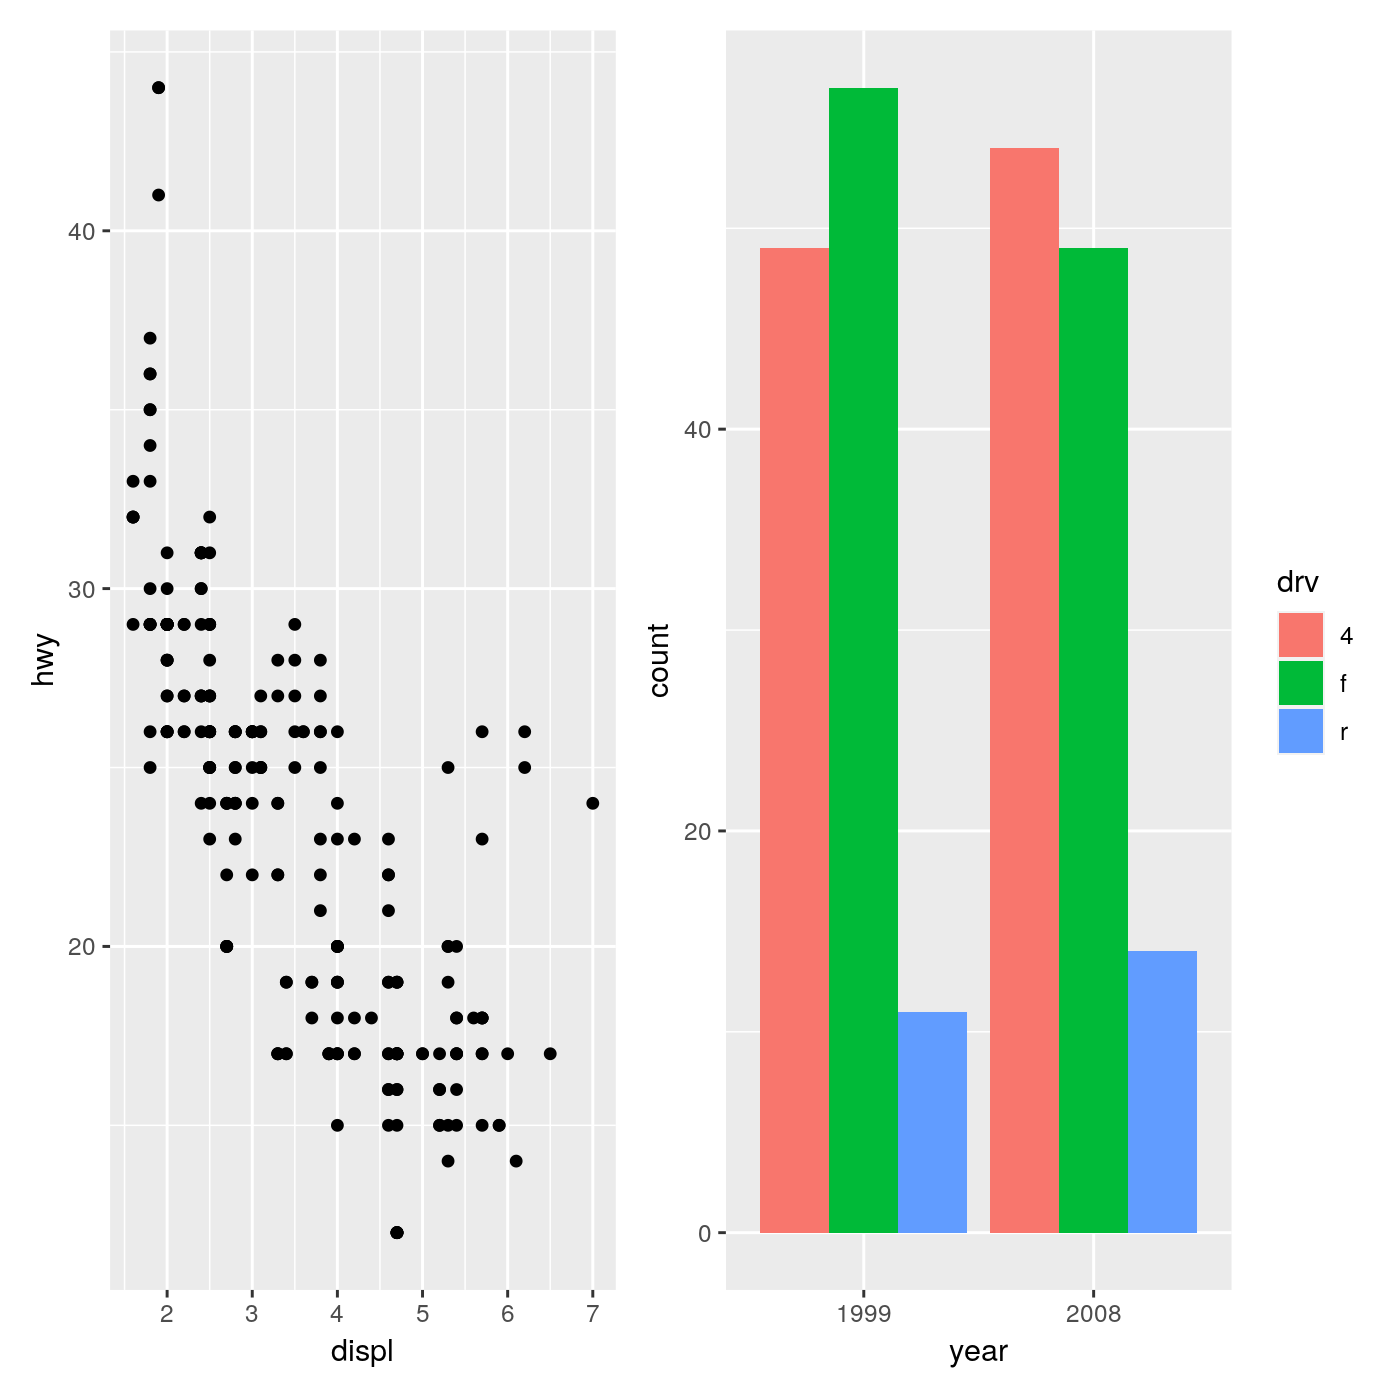

In [84]:
p1+p2

`-` p1~p4를 합침 

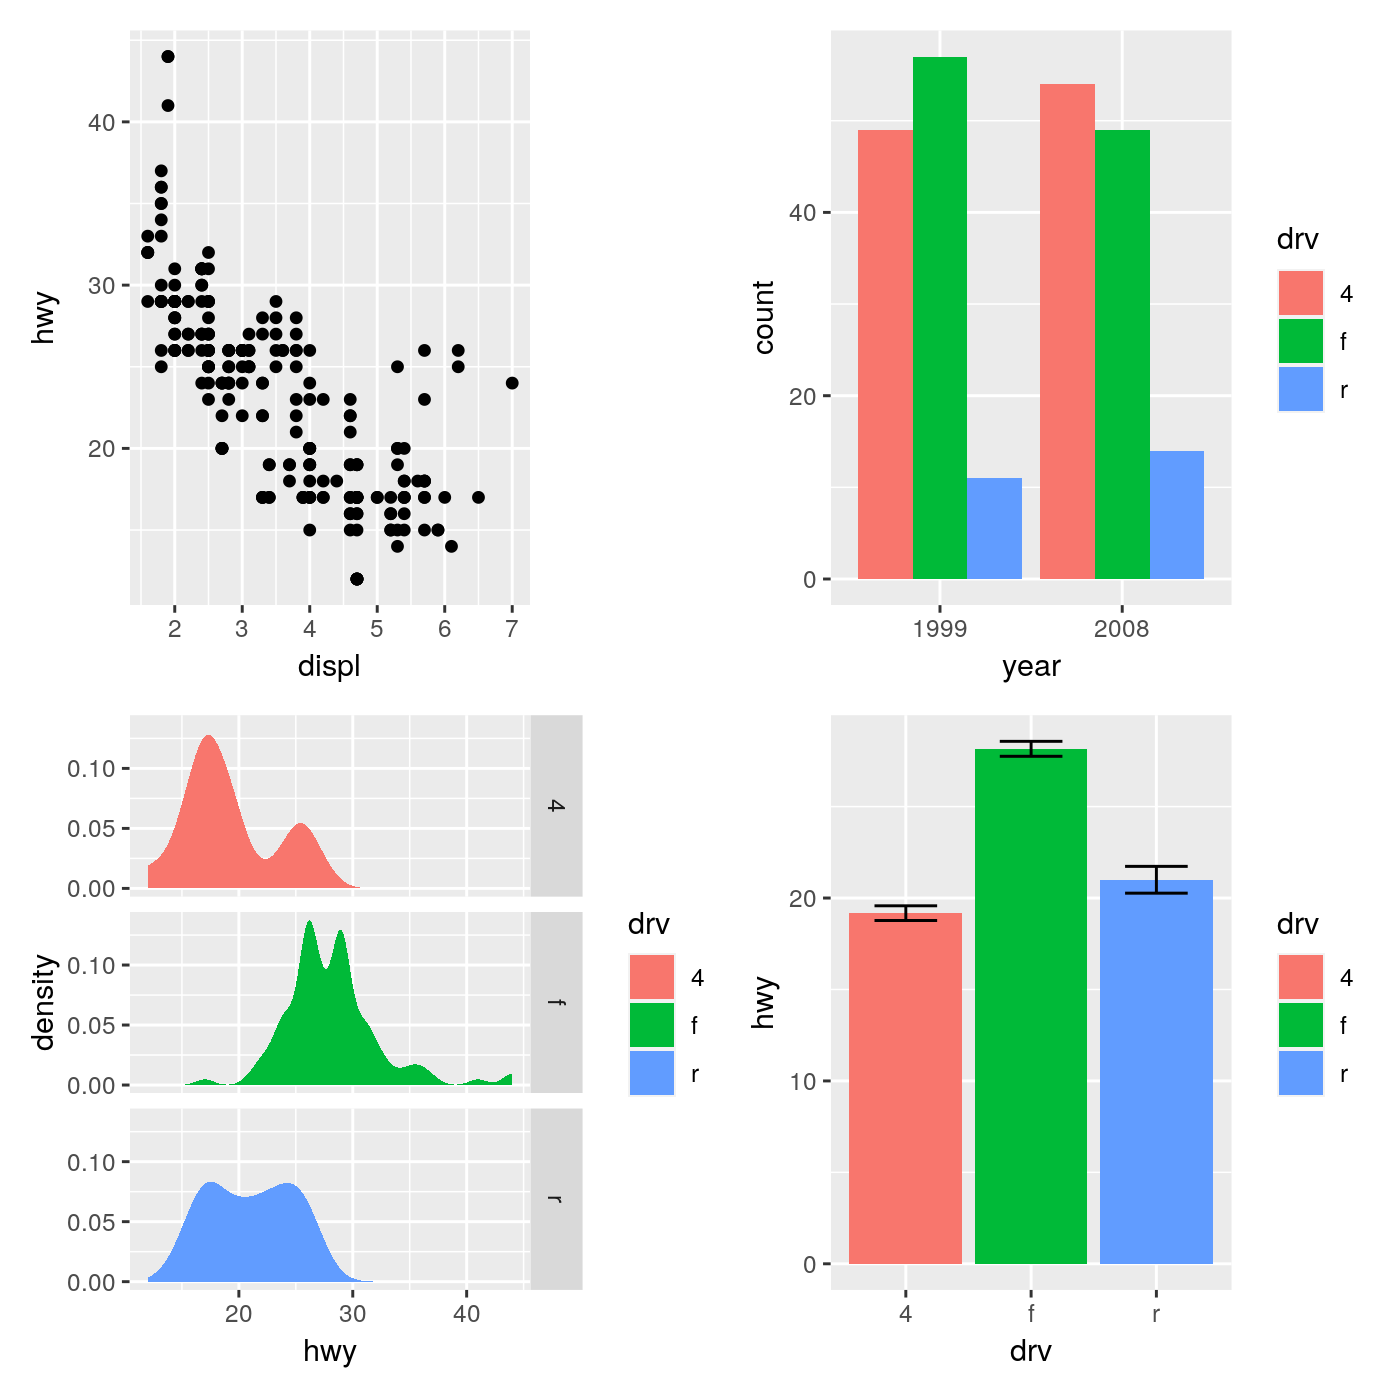

In [85]:
p1+p2+p3+p4

### 연산자 

`-` p1~p4 정의 

In [86]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` p1, p2 를 위아래로 합침 

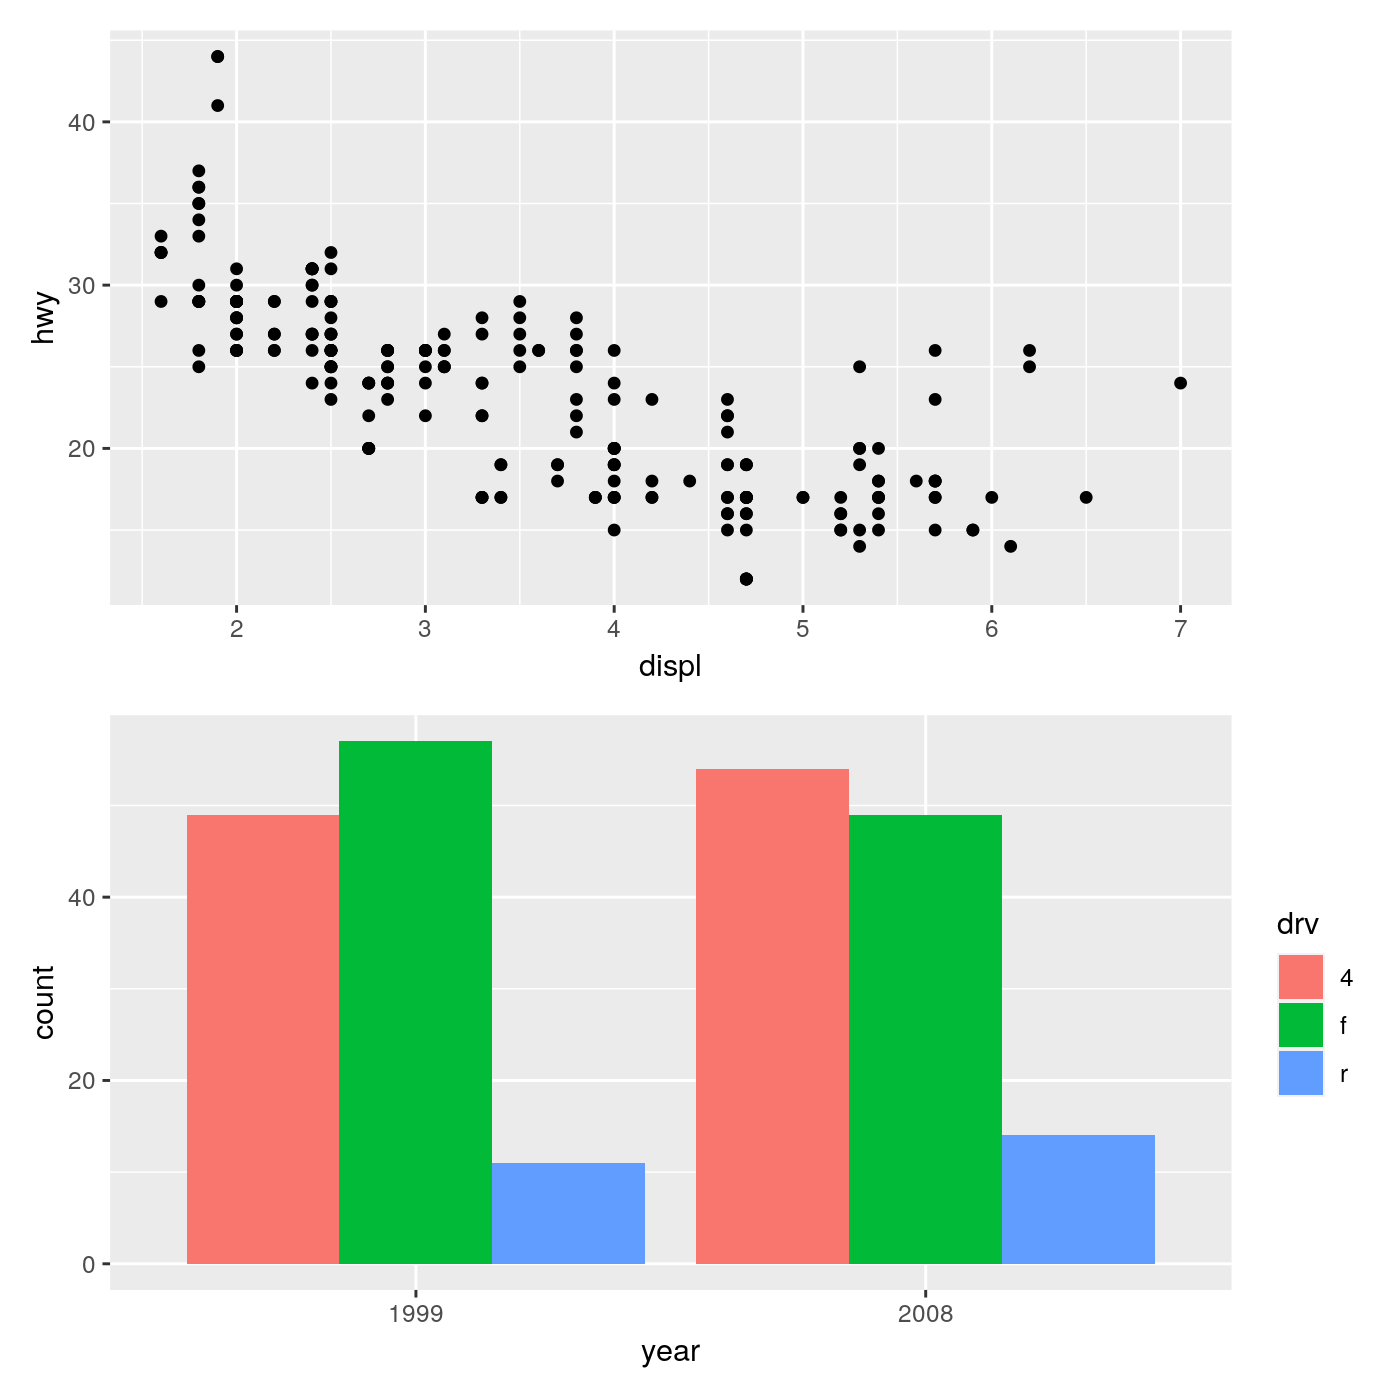

In [73]:
p1 / p2

`-` p1, p2를 좌우로 합침 

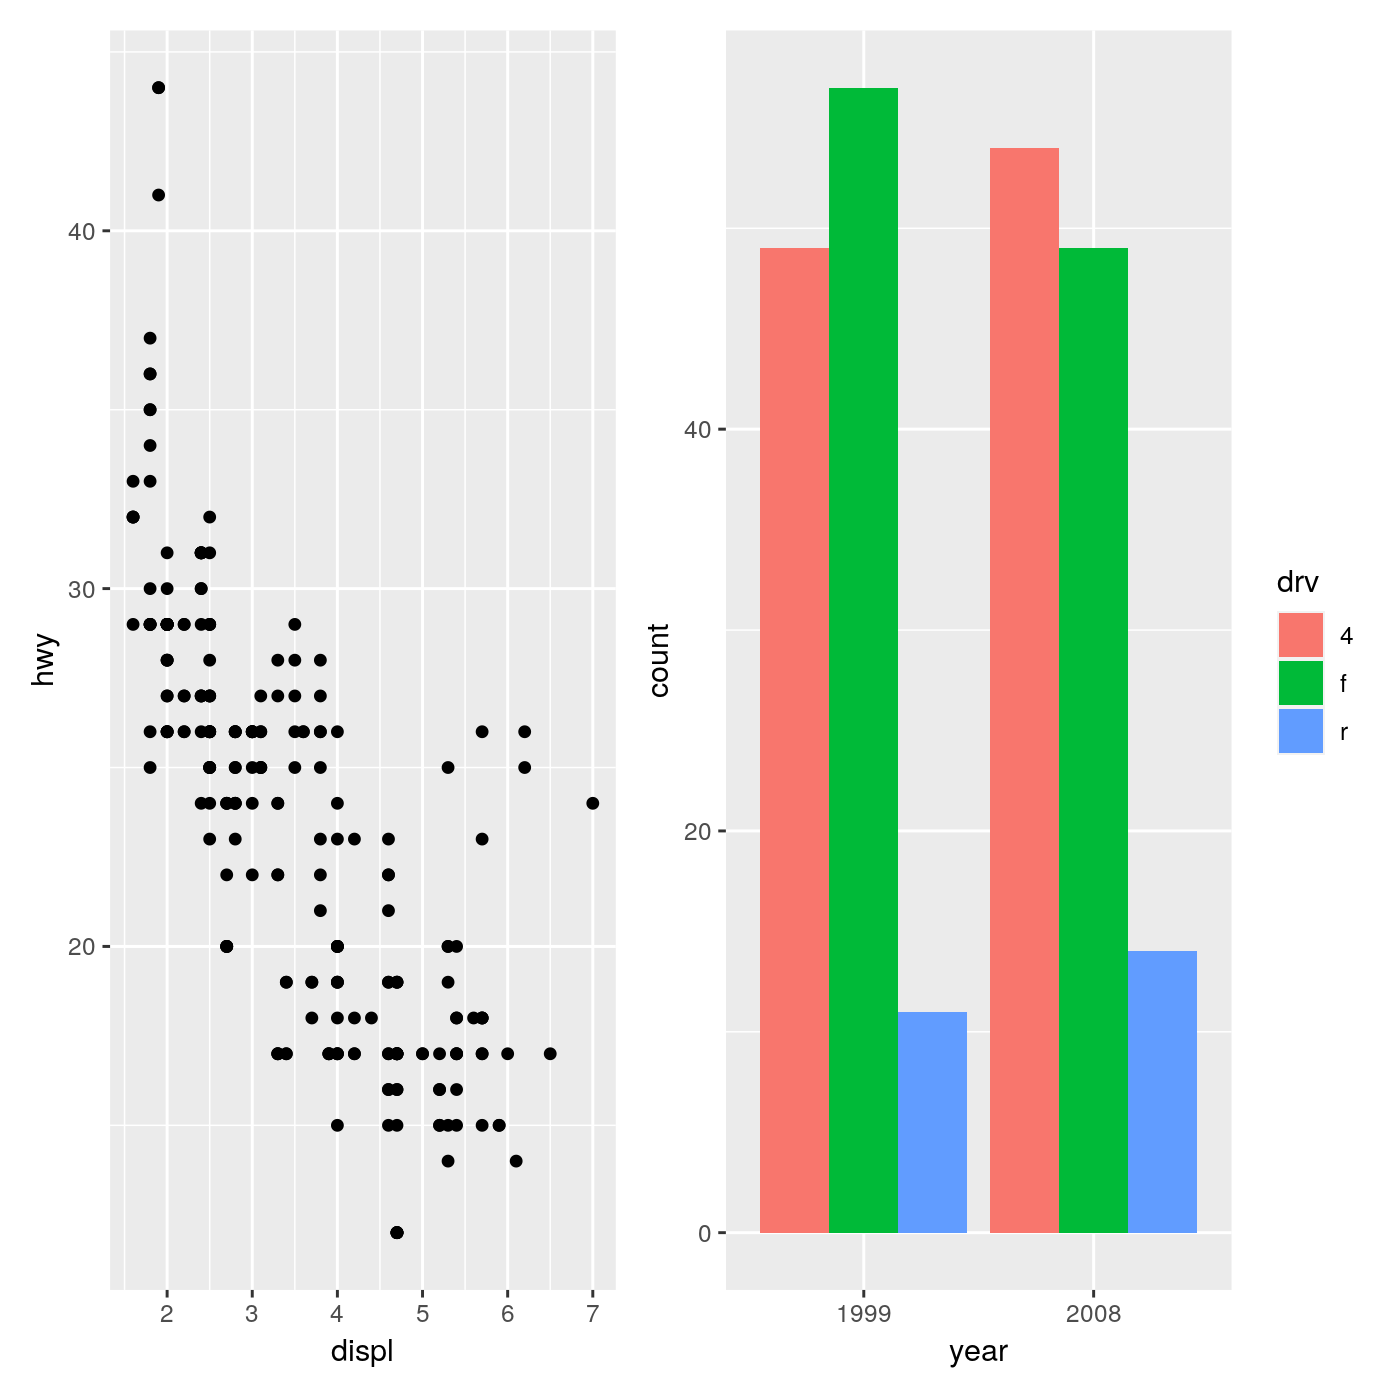

In [74]:
p1 | p2

`-` 다양한 응용가능 1 

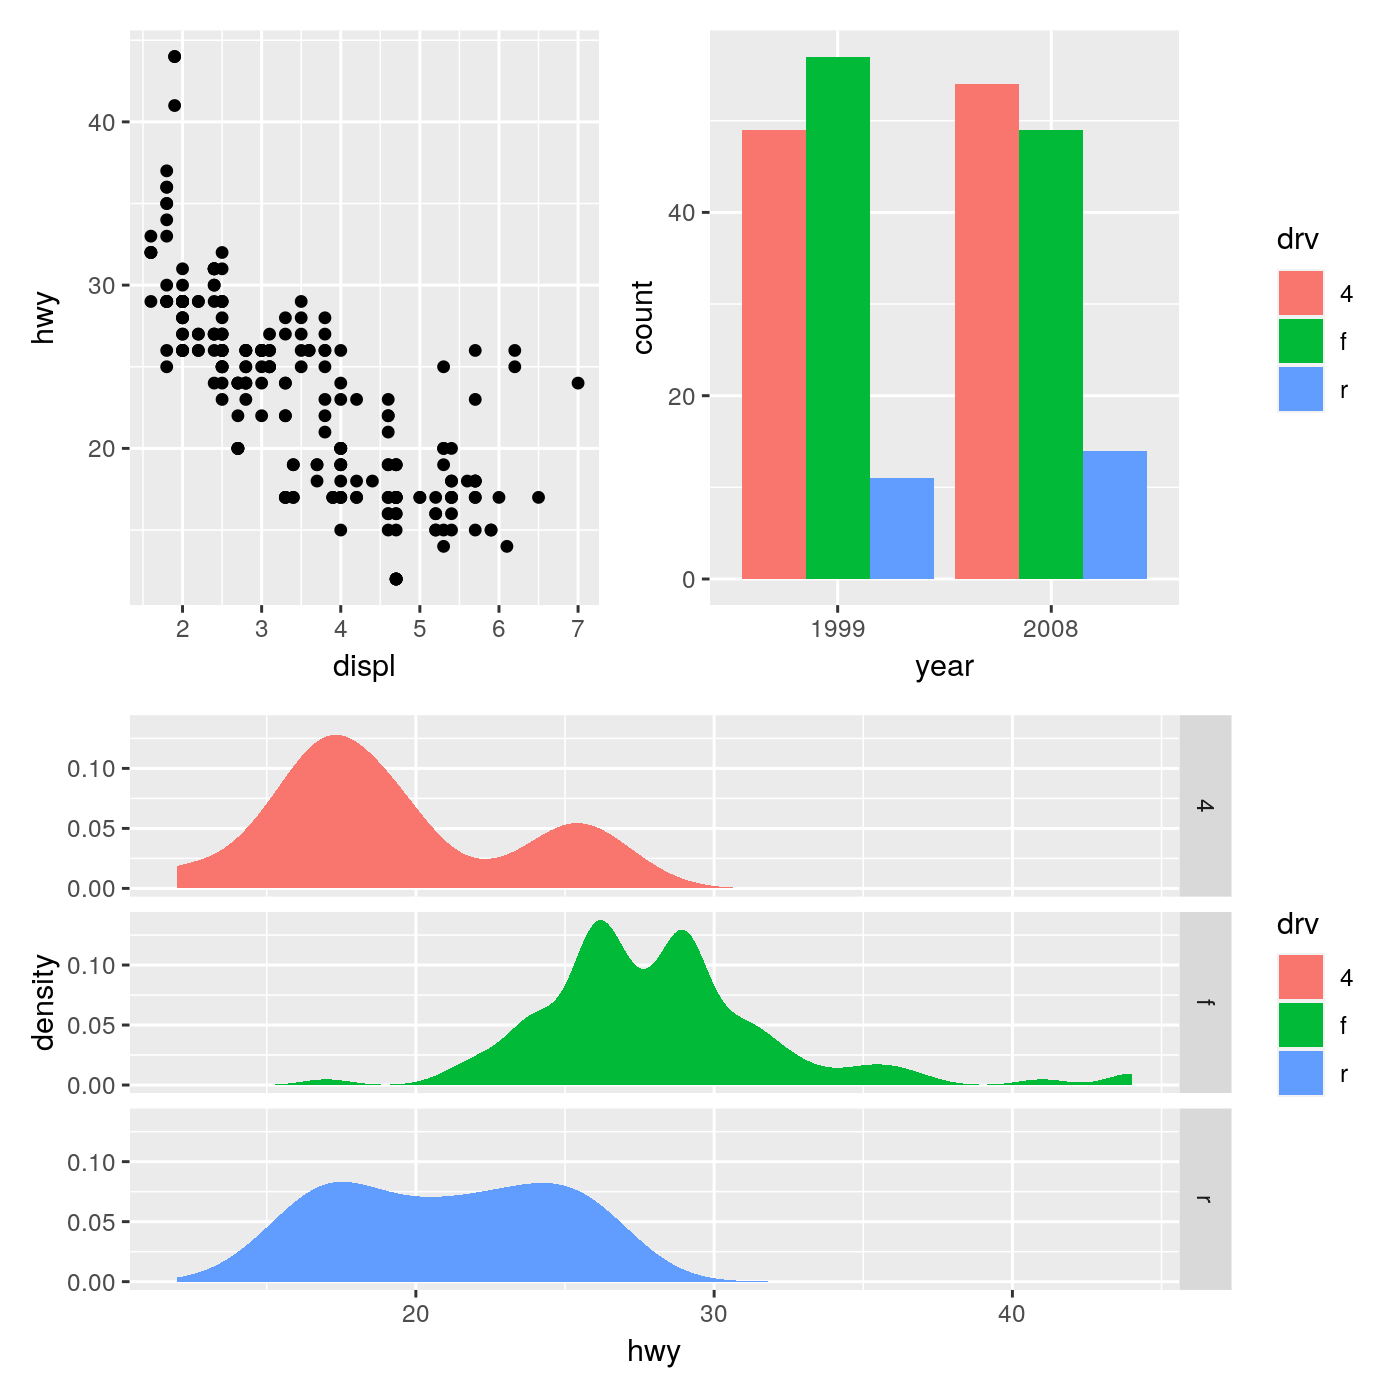

In [75]:
(p1 | p2) / p3 

`-` 다양한 응용가능 2

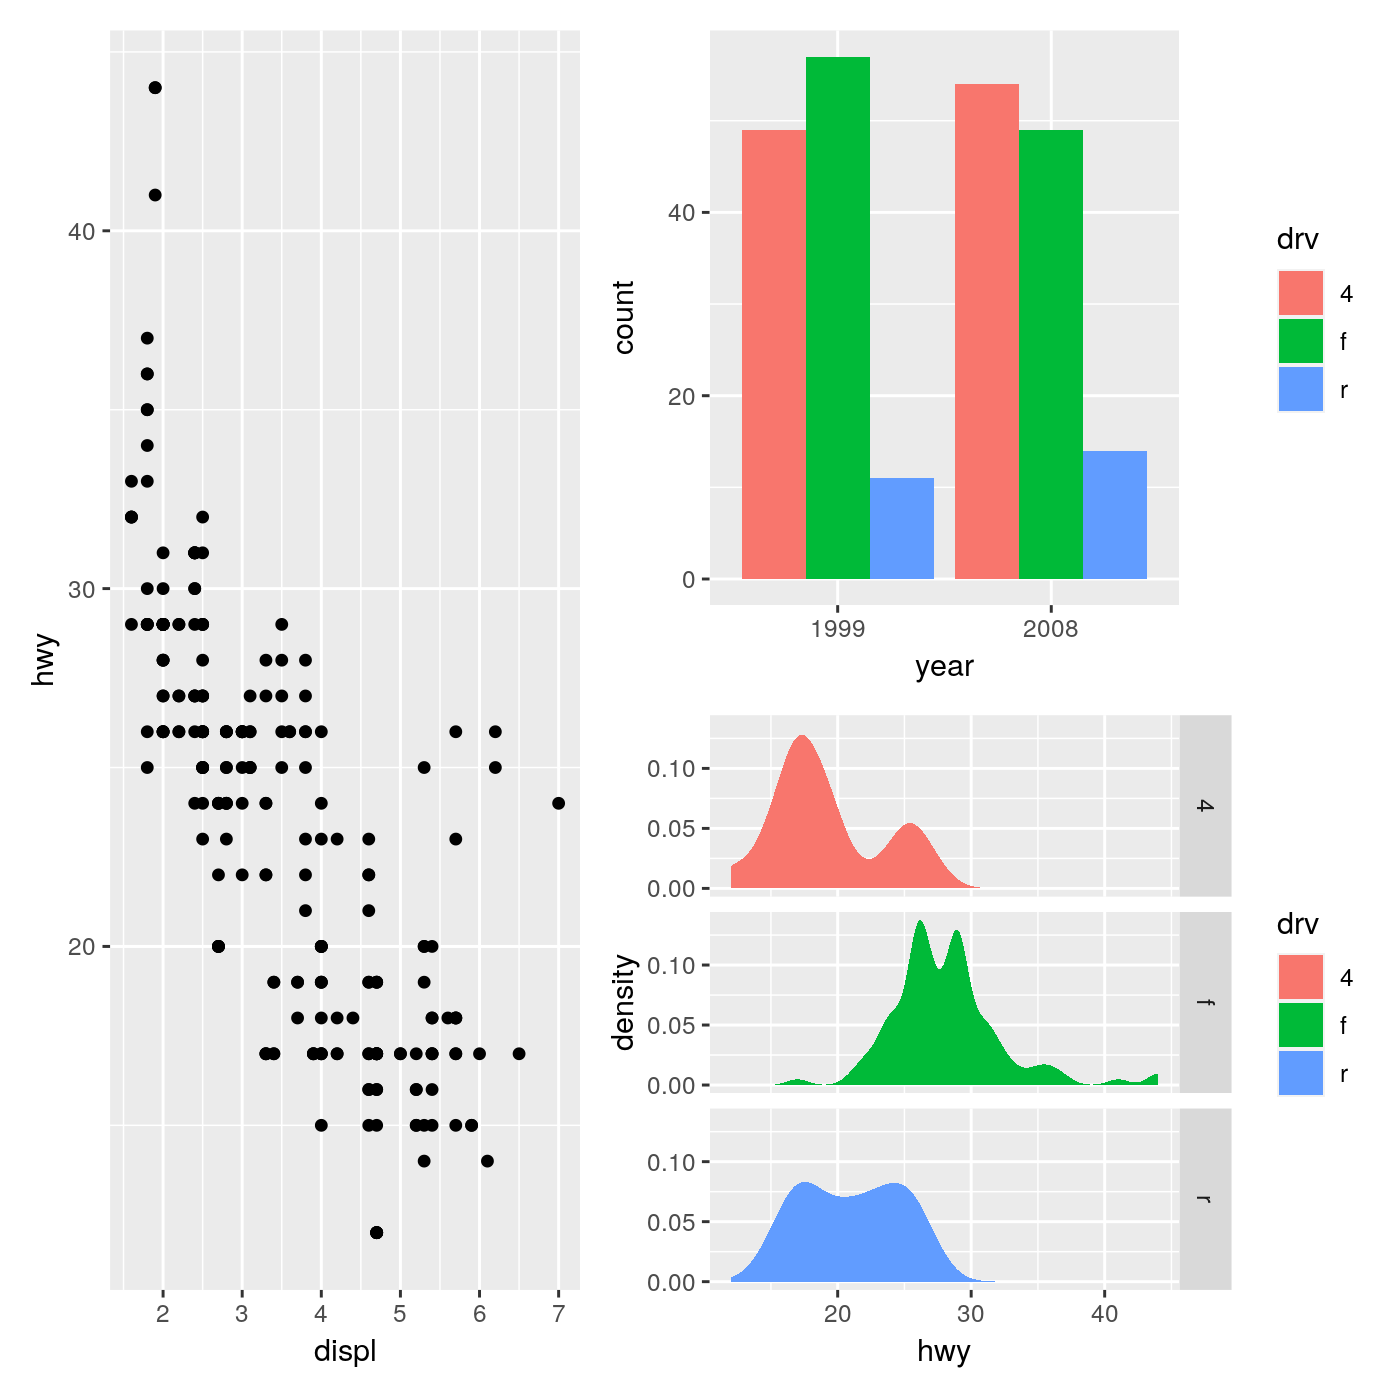

In [78]:
p1 | (p2 / p3)

`-` 다양한 응용가능 3

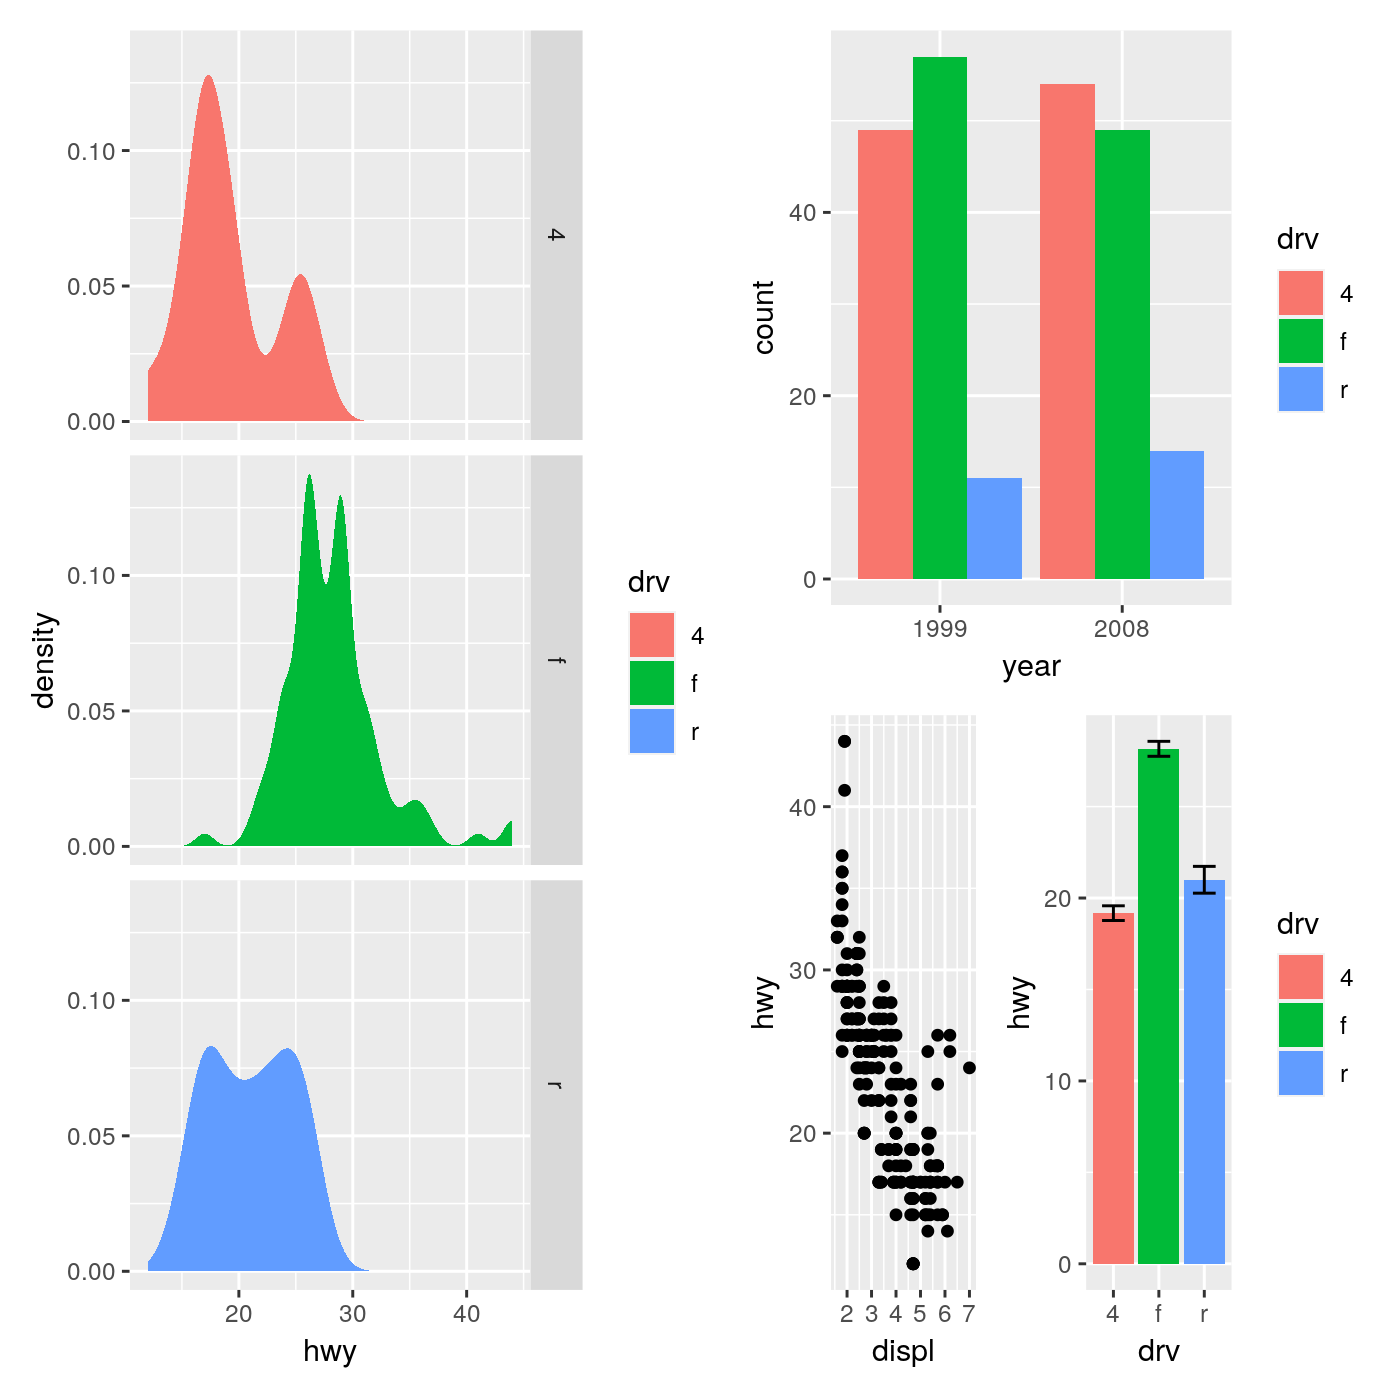

In [79]:
p3 | (p2 / (p1|p4))

### layout 

`-` p1~p4 정의 

In [120]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy, color = class))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` p1,p2,p3 를 합치는데 layout을 조정 

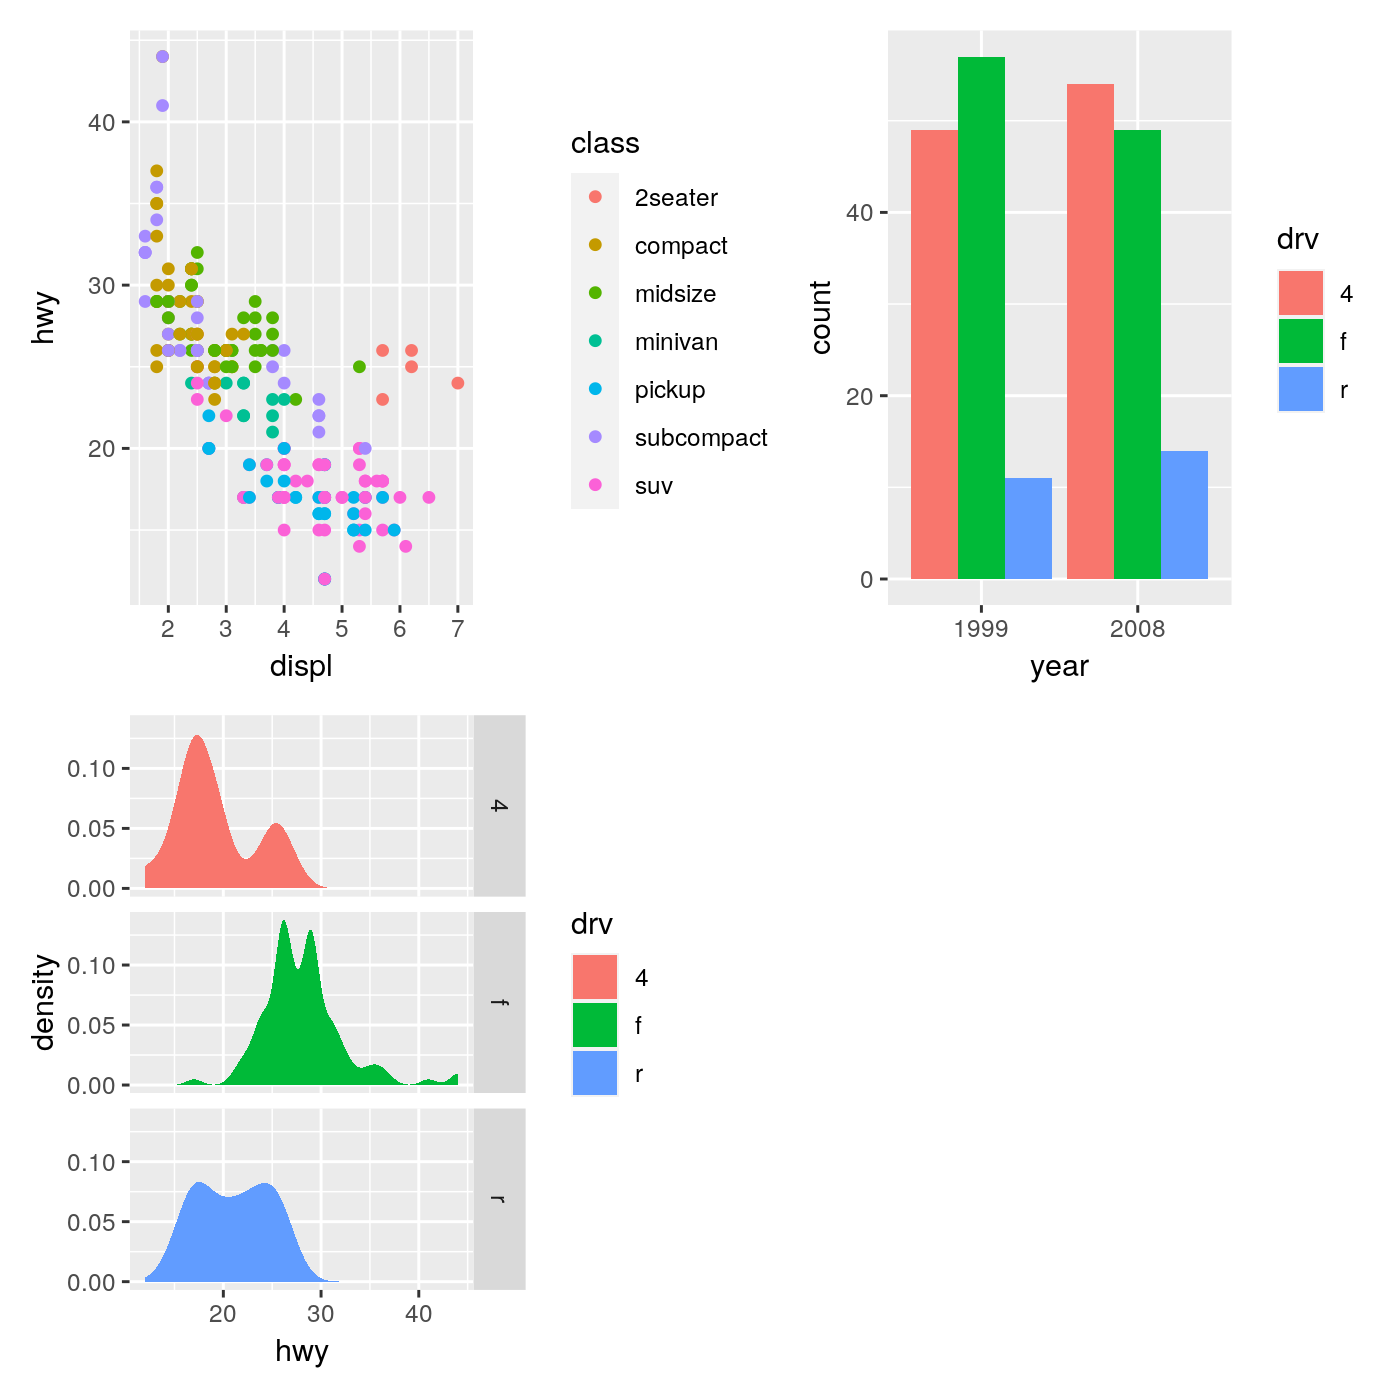

In [121]:
p1 + p2 + p3 + plot_layout(ncol = 2)

`-` 범례 가이드를 한쪽으로 정리하고 싶다면? 

(step1) 원래그림 

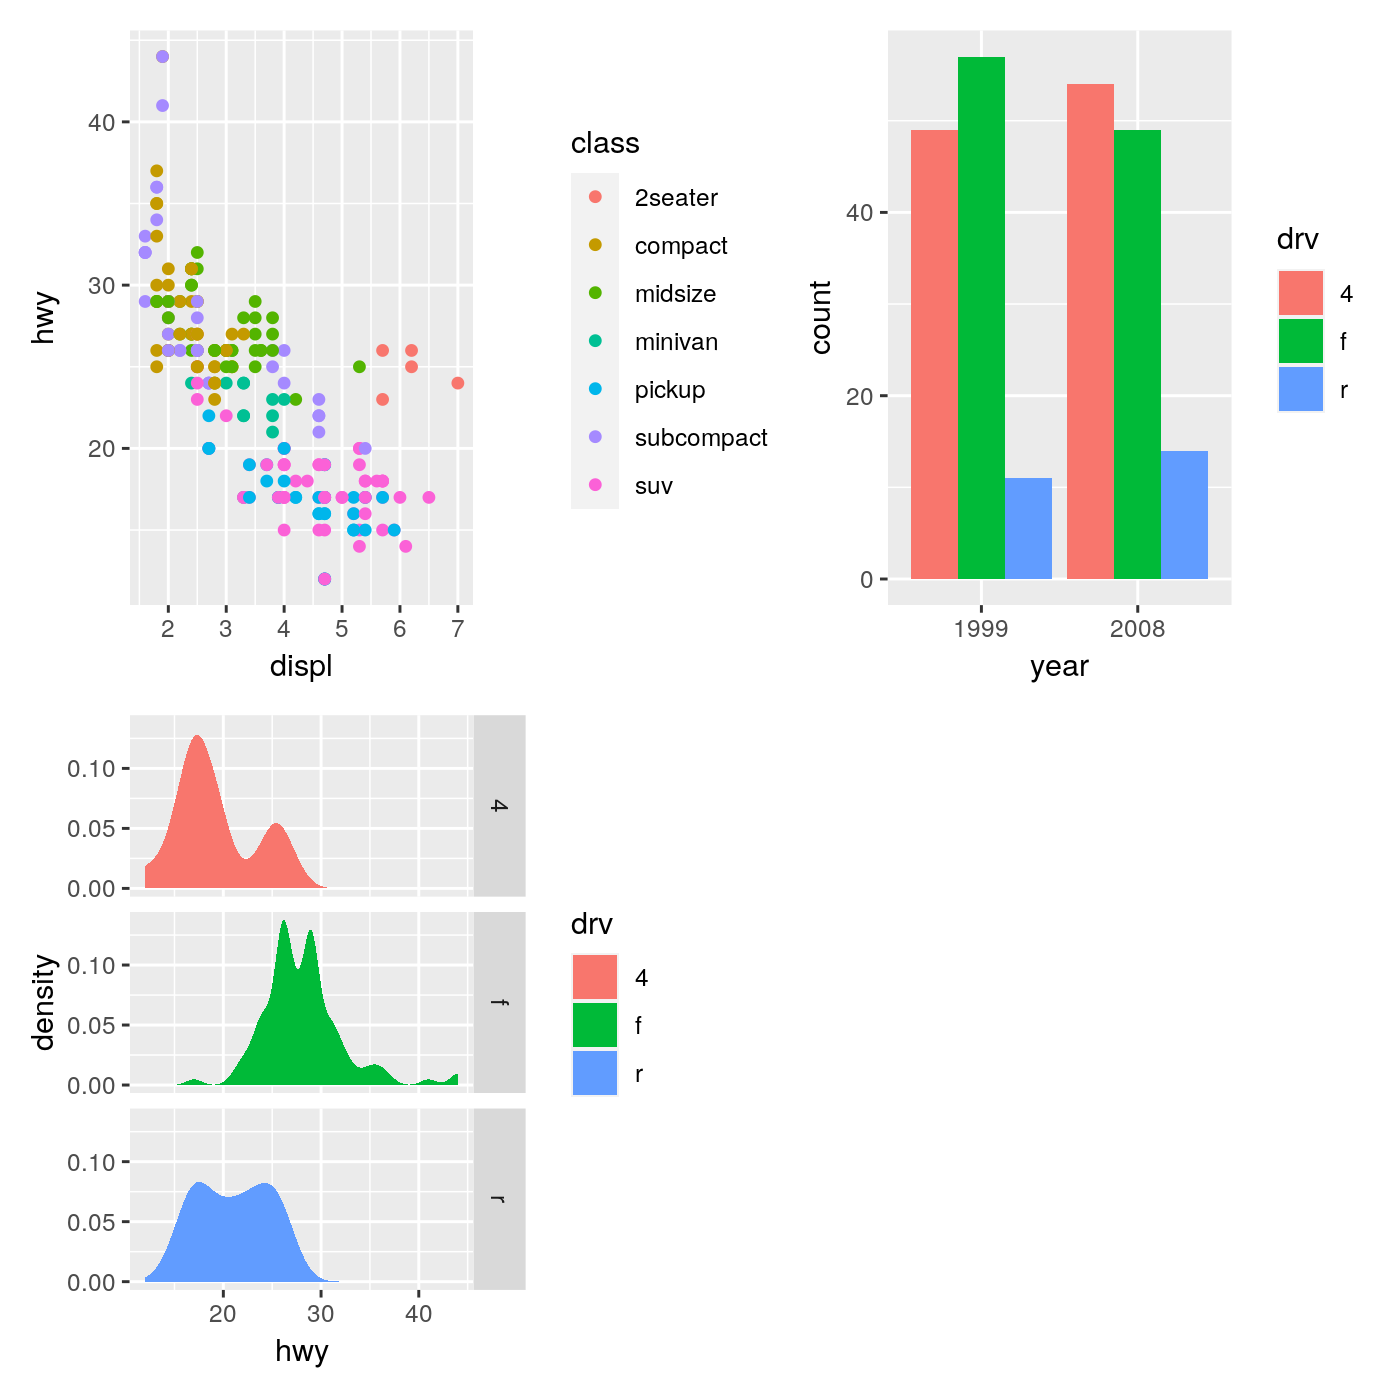

In [122]:
p1 + p2 + p3 + plot_layout(ncol = 2)

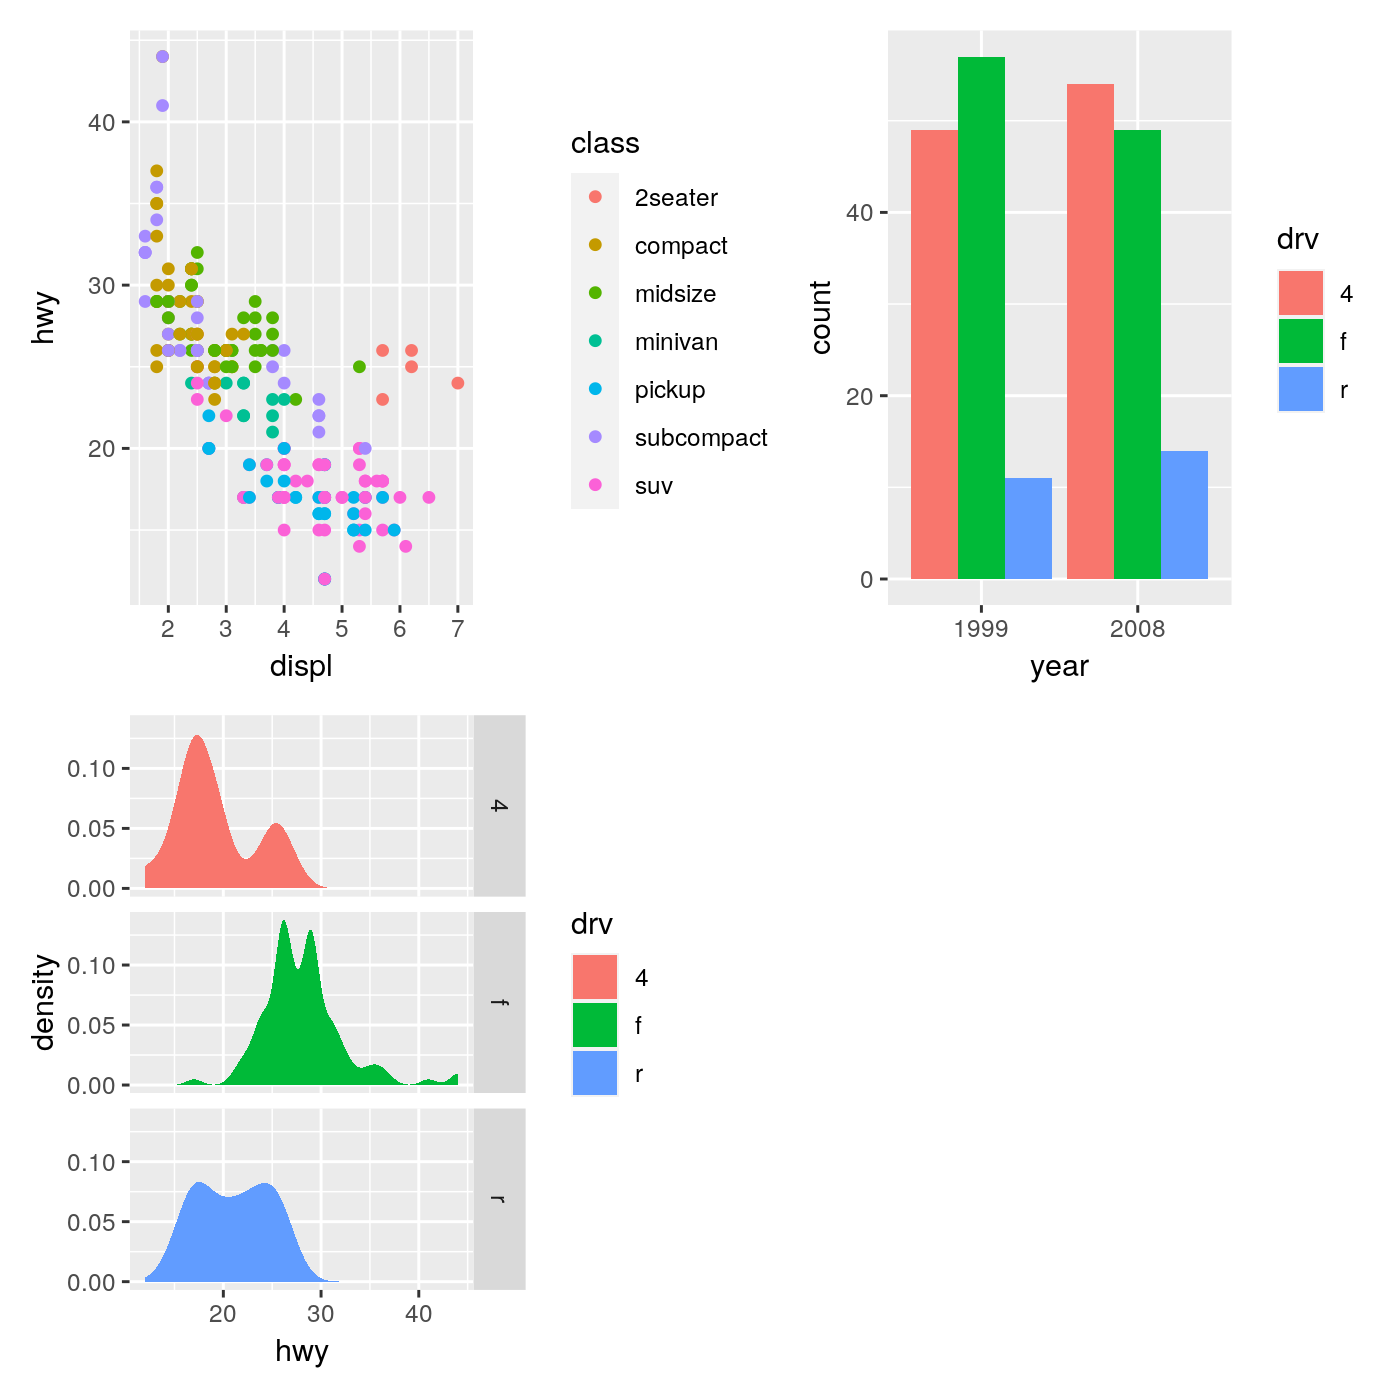

In [123]:
p1 + p2 + p3 + plot_layout(ncol = 2)

(step2) 가이드를 모음

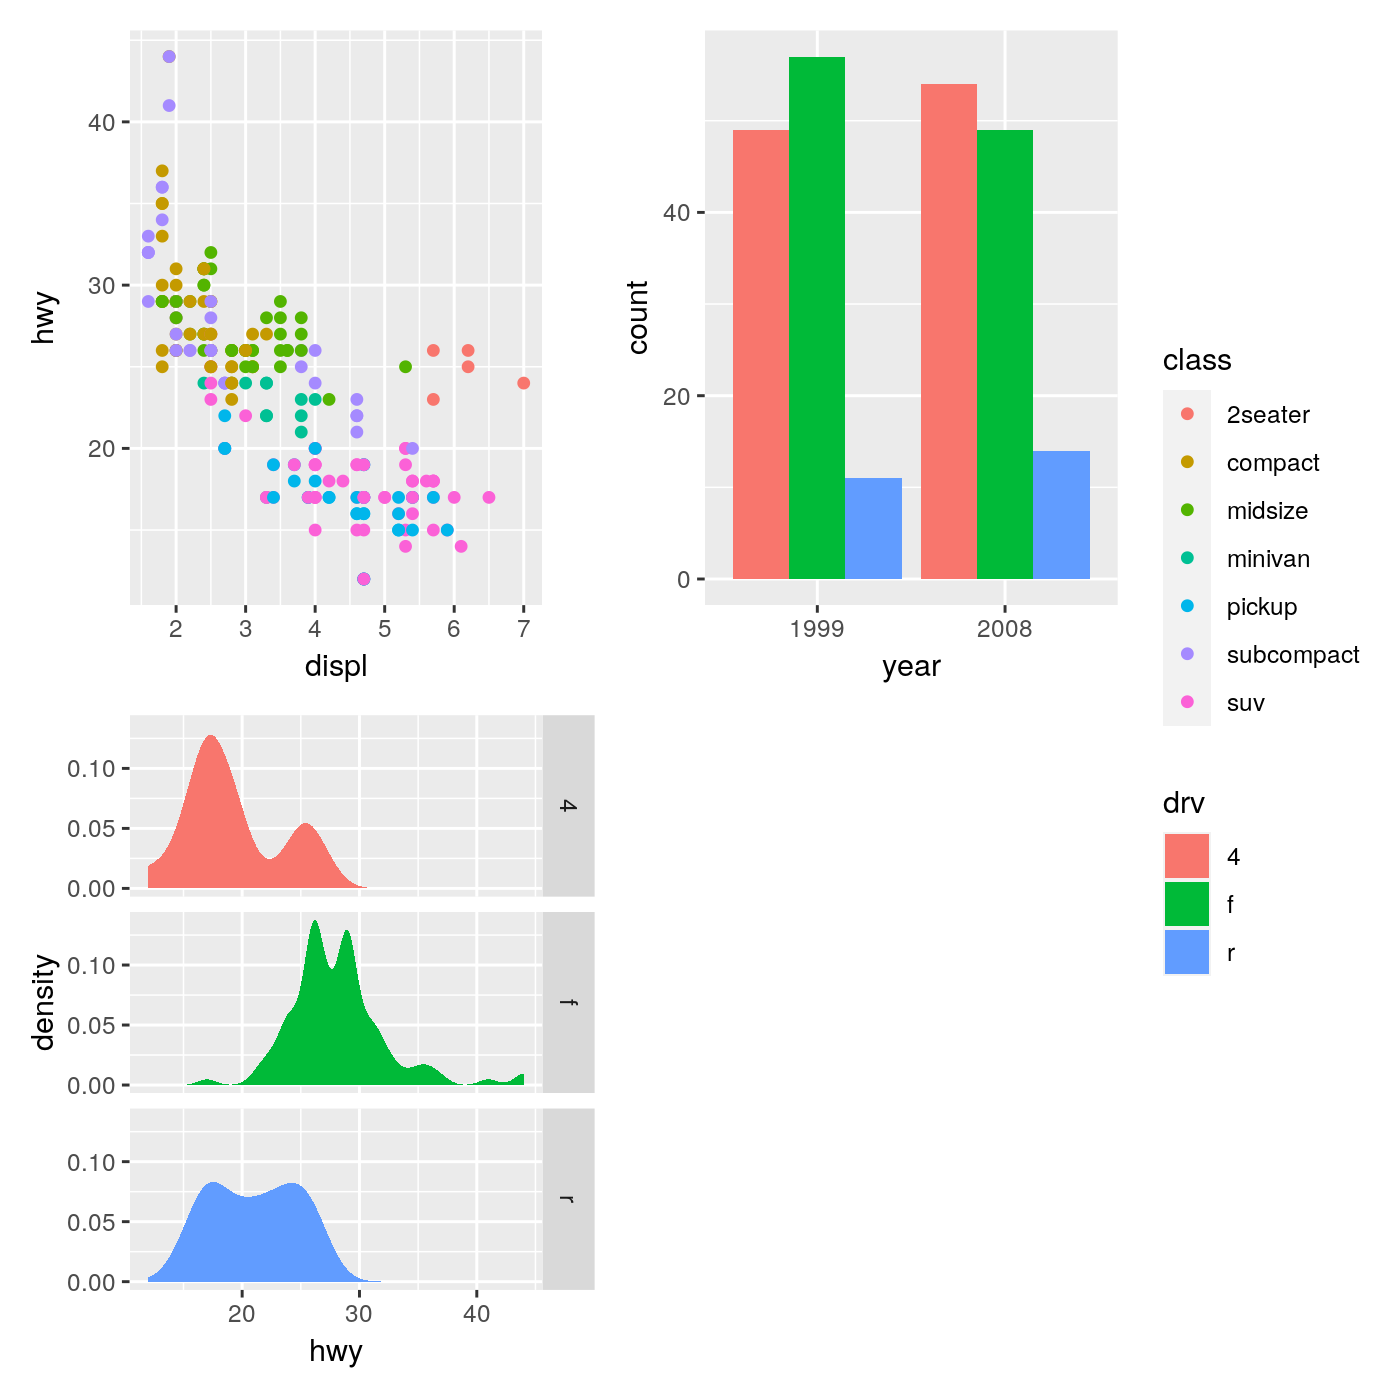

In [124]:
p1 + p2 + p3 + plot_layout(ncol = 2, guides="collect")

(step3) 가이드에어리어를 따로 만들어줌 

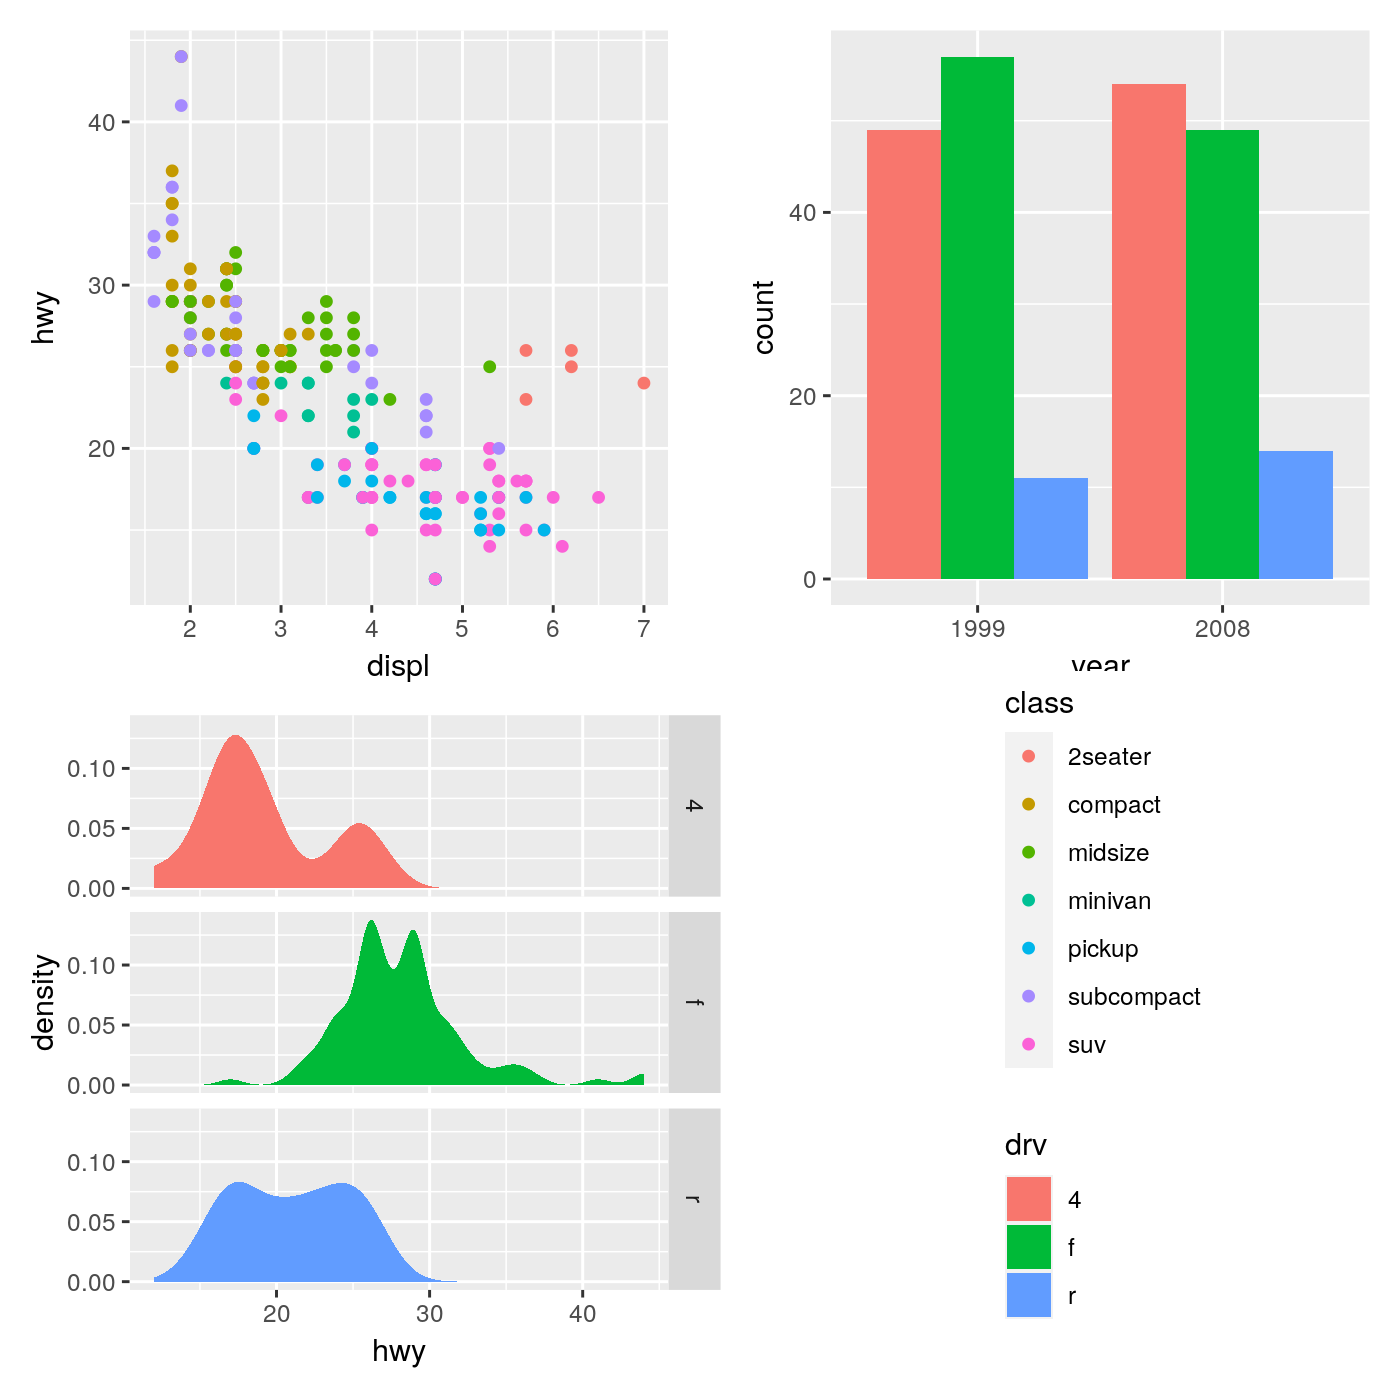

In [125]:
p1 + p2 + p3 + guide_area()+plot_layout(ncol = 2, guides="collect")

### Modifying subplots

`-` p1~p4 정의 

In [159]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy, color = class))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` 첫번째 그림 테마 변경 

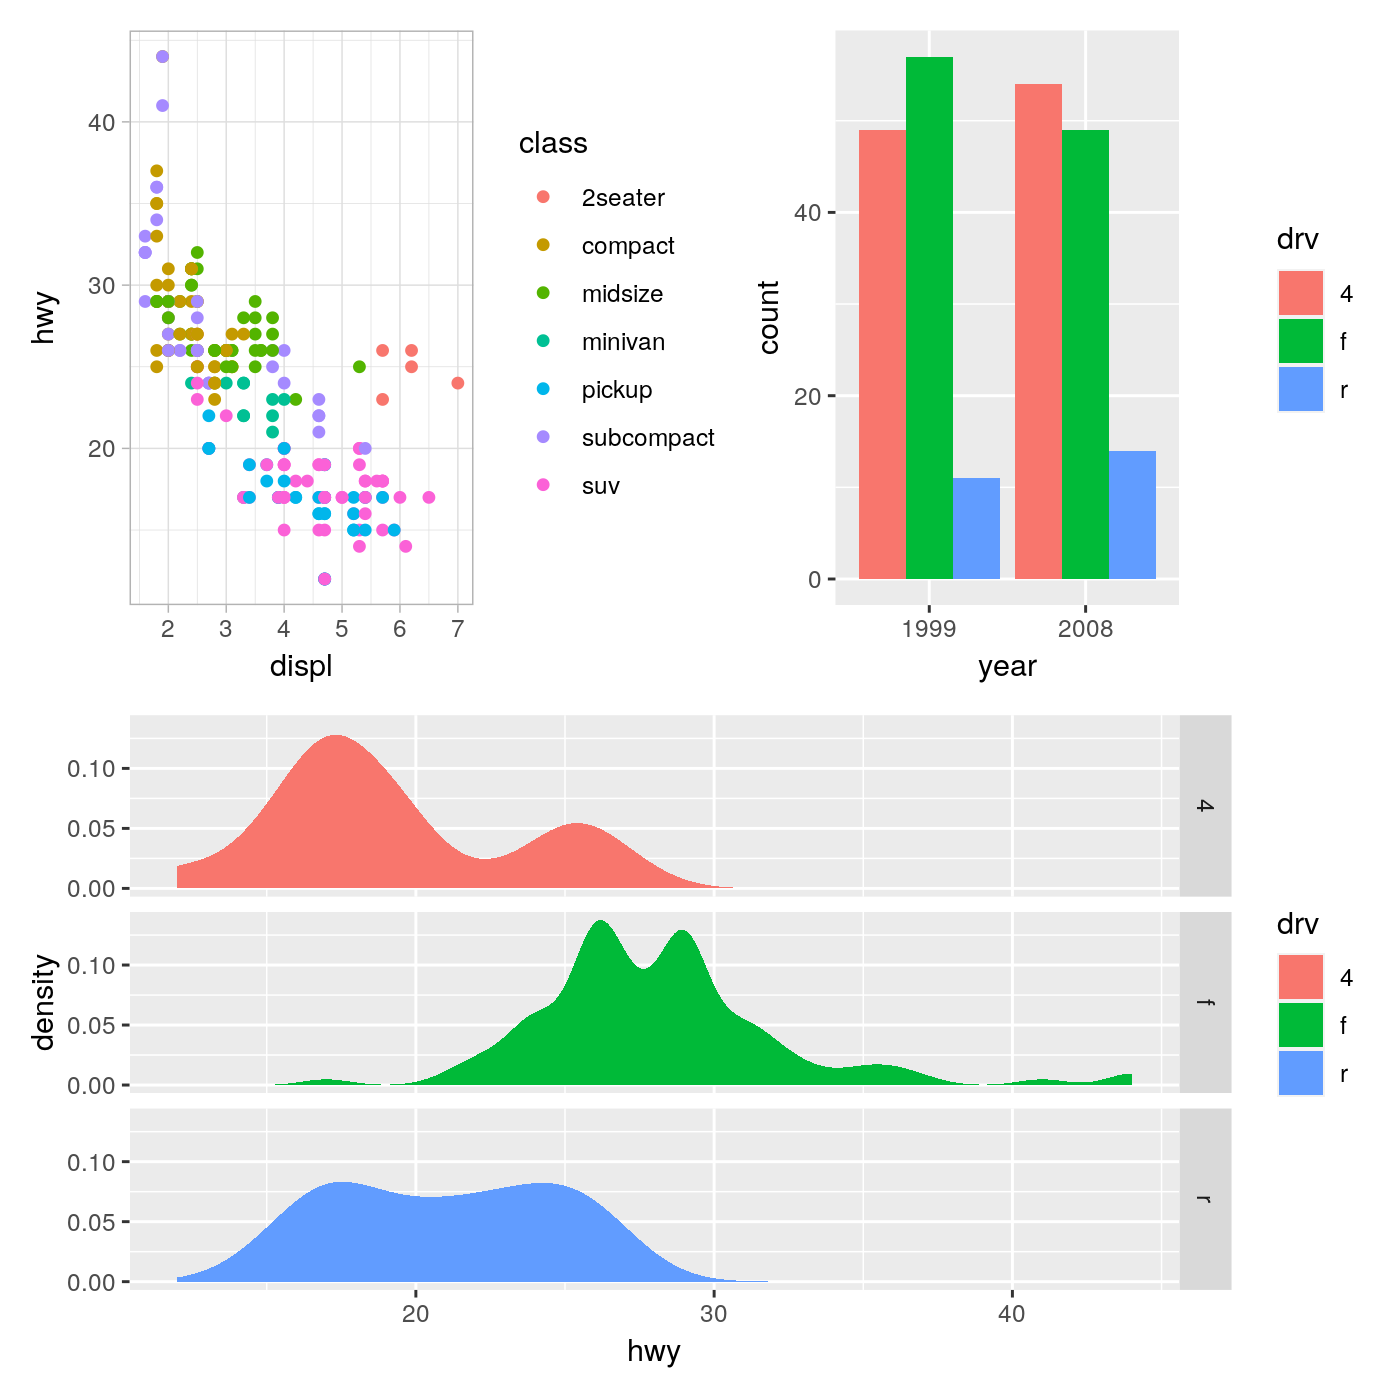

In [146]:
p <- (p1 + p2) / p3 
p[[1]][[1]] <- p[[1]][[1]] + theme_light()
p

`-` 두번째 그림 테마변경 

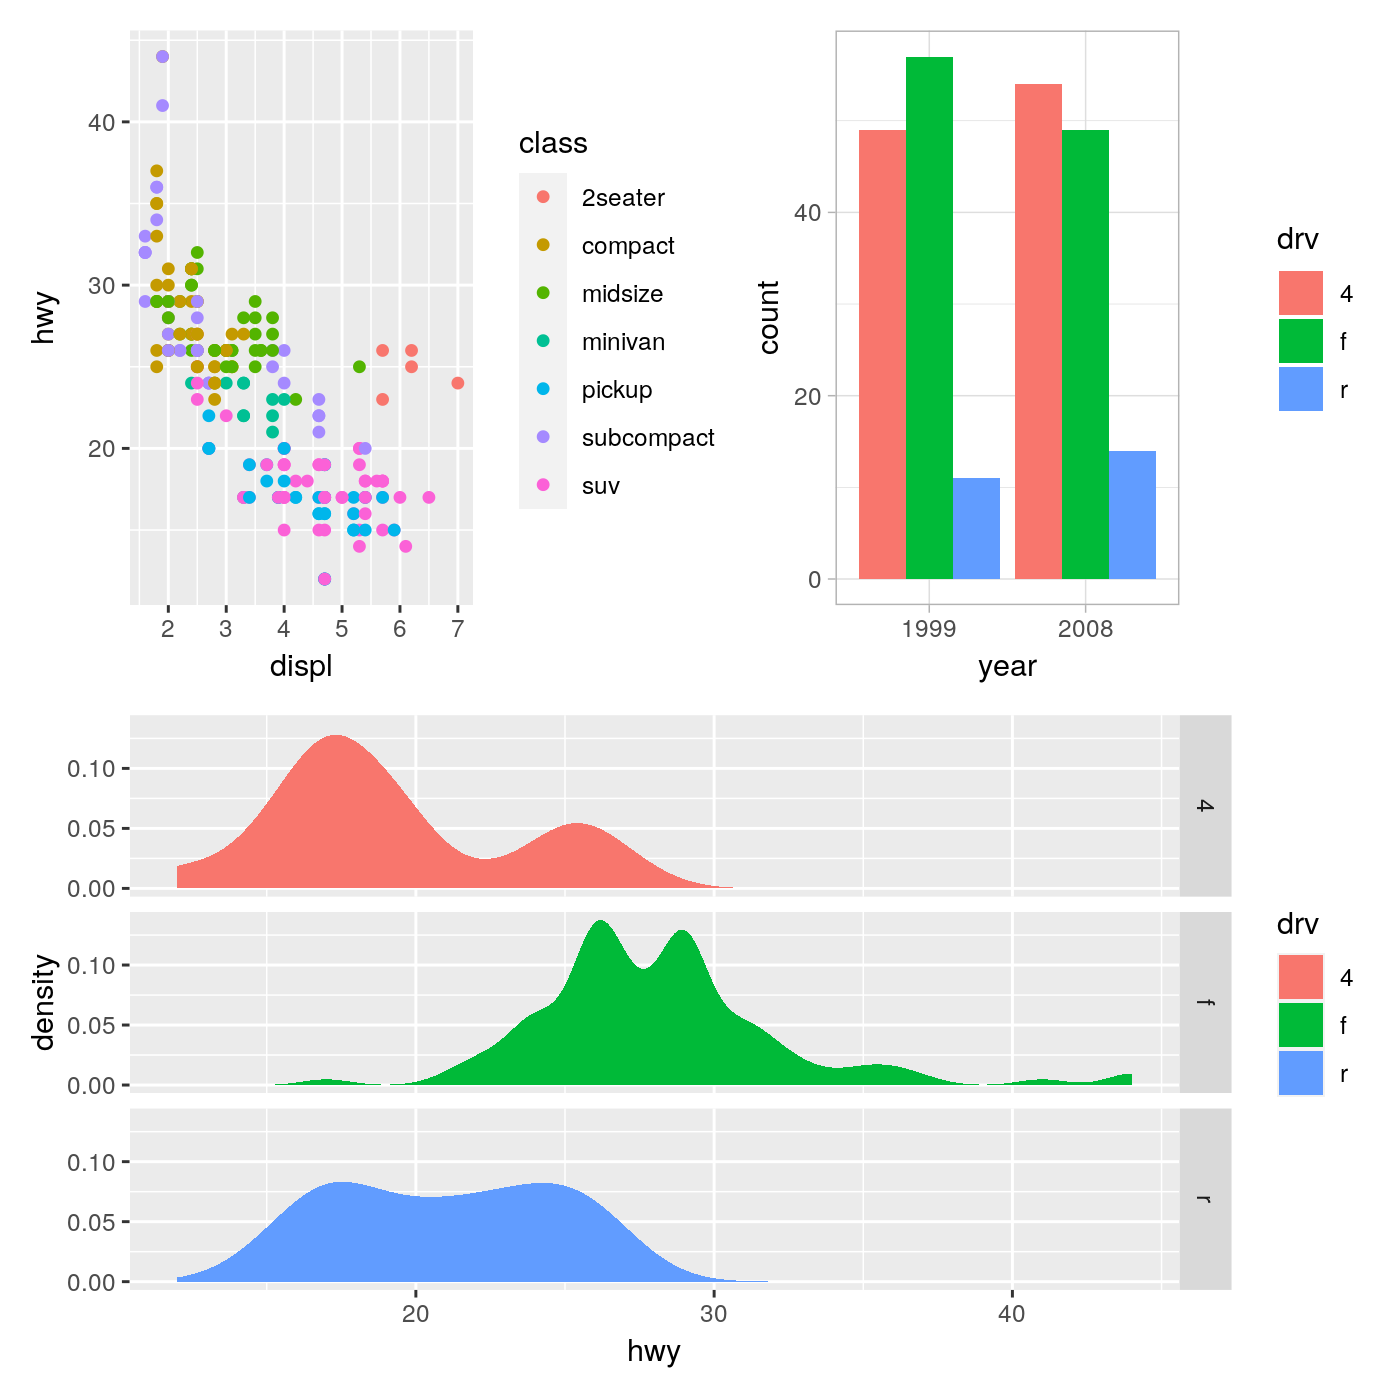

In [147]:
p <- (p1 + p2) / p3 
p[[1]][[2]] <- p[[1]][[2]] + theme_light()
p

`-` 세번째 그림 테마변경 

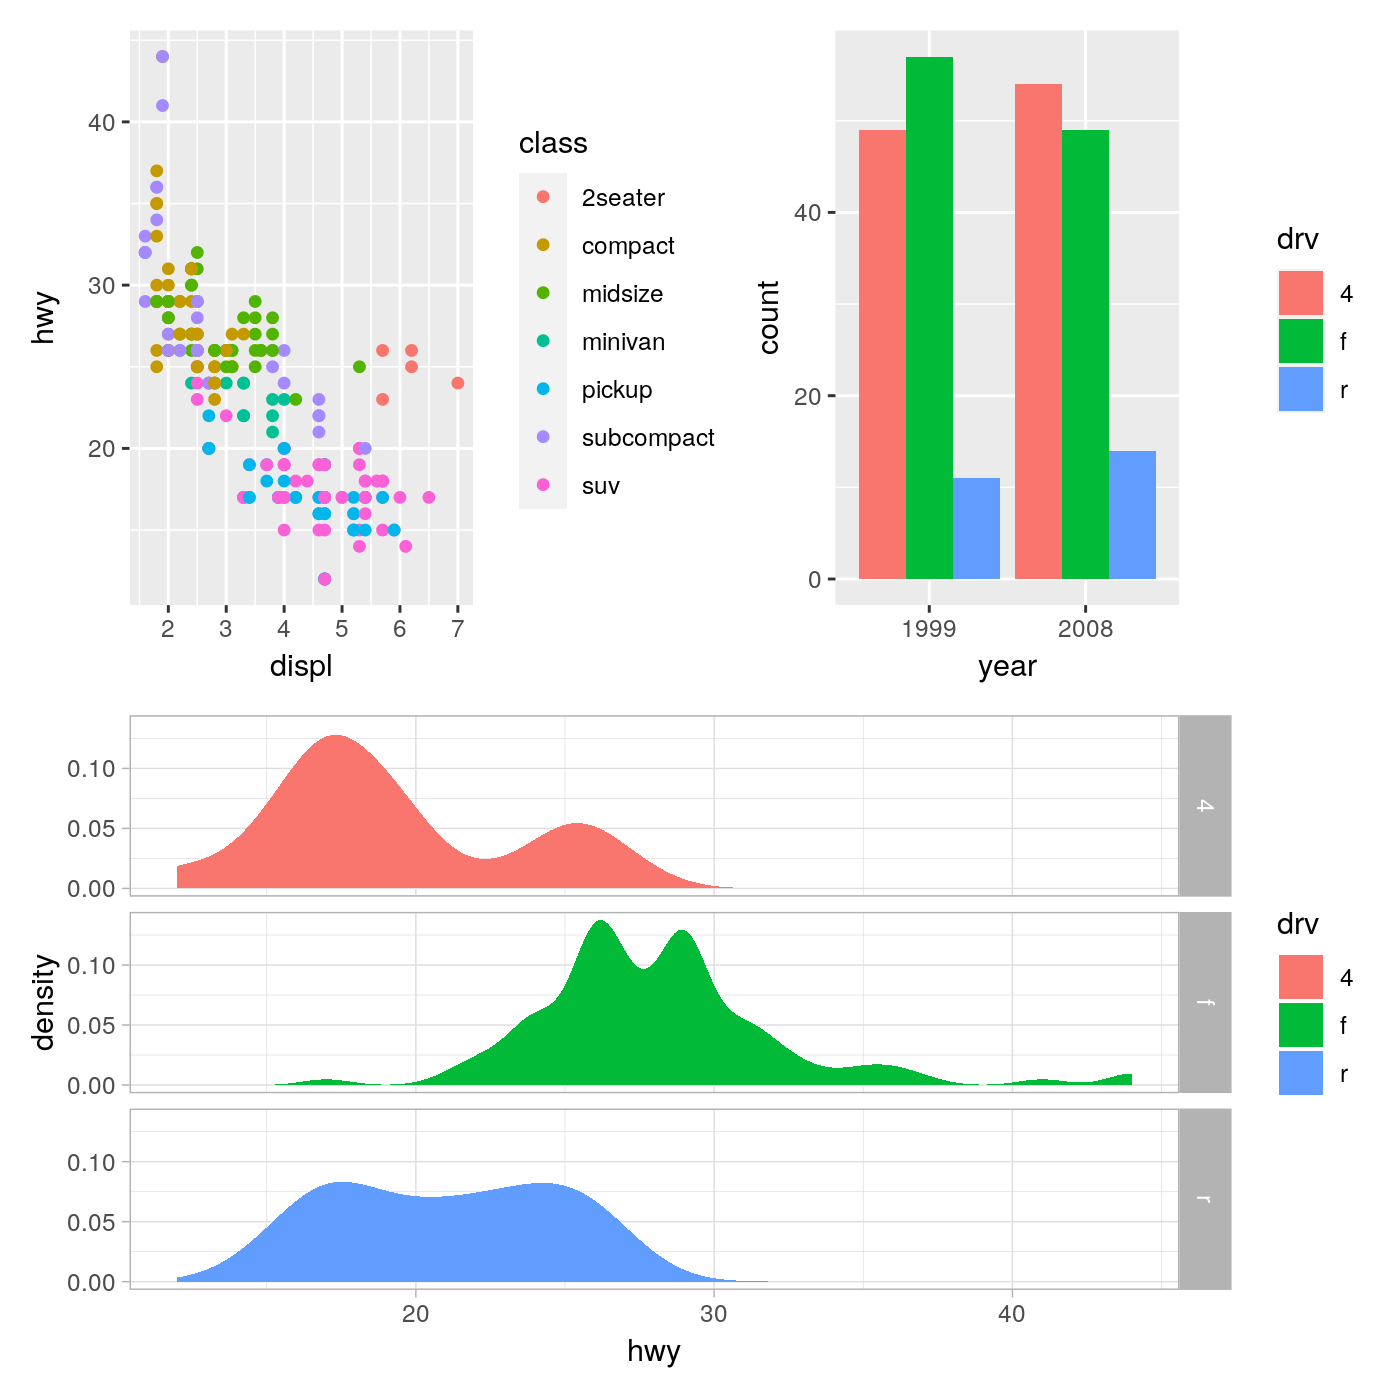

In [148]:
p <- (p1 + p2) / p3 
p[[2]] <- p[[2]] + theme_light()
p

`-` 모든서브플랏의 테마변경 

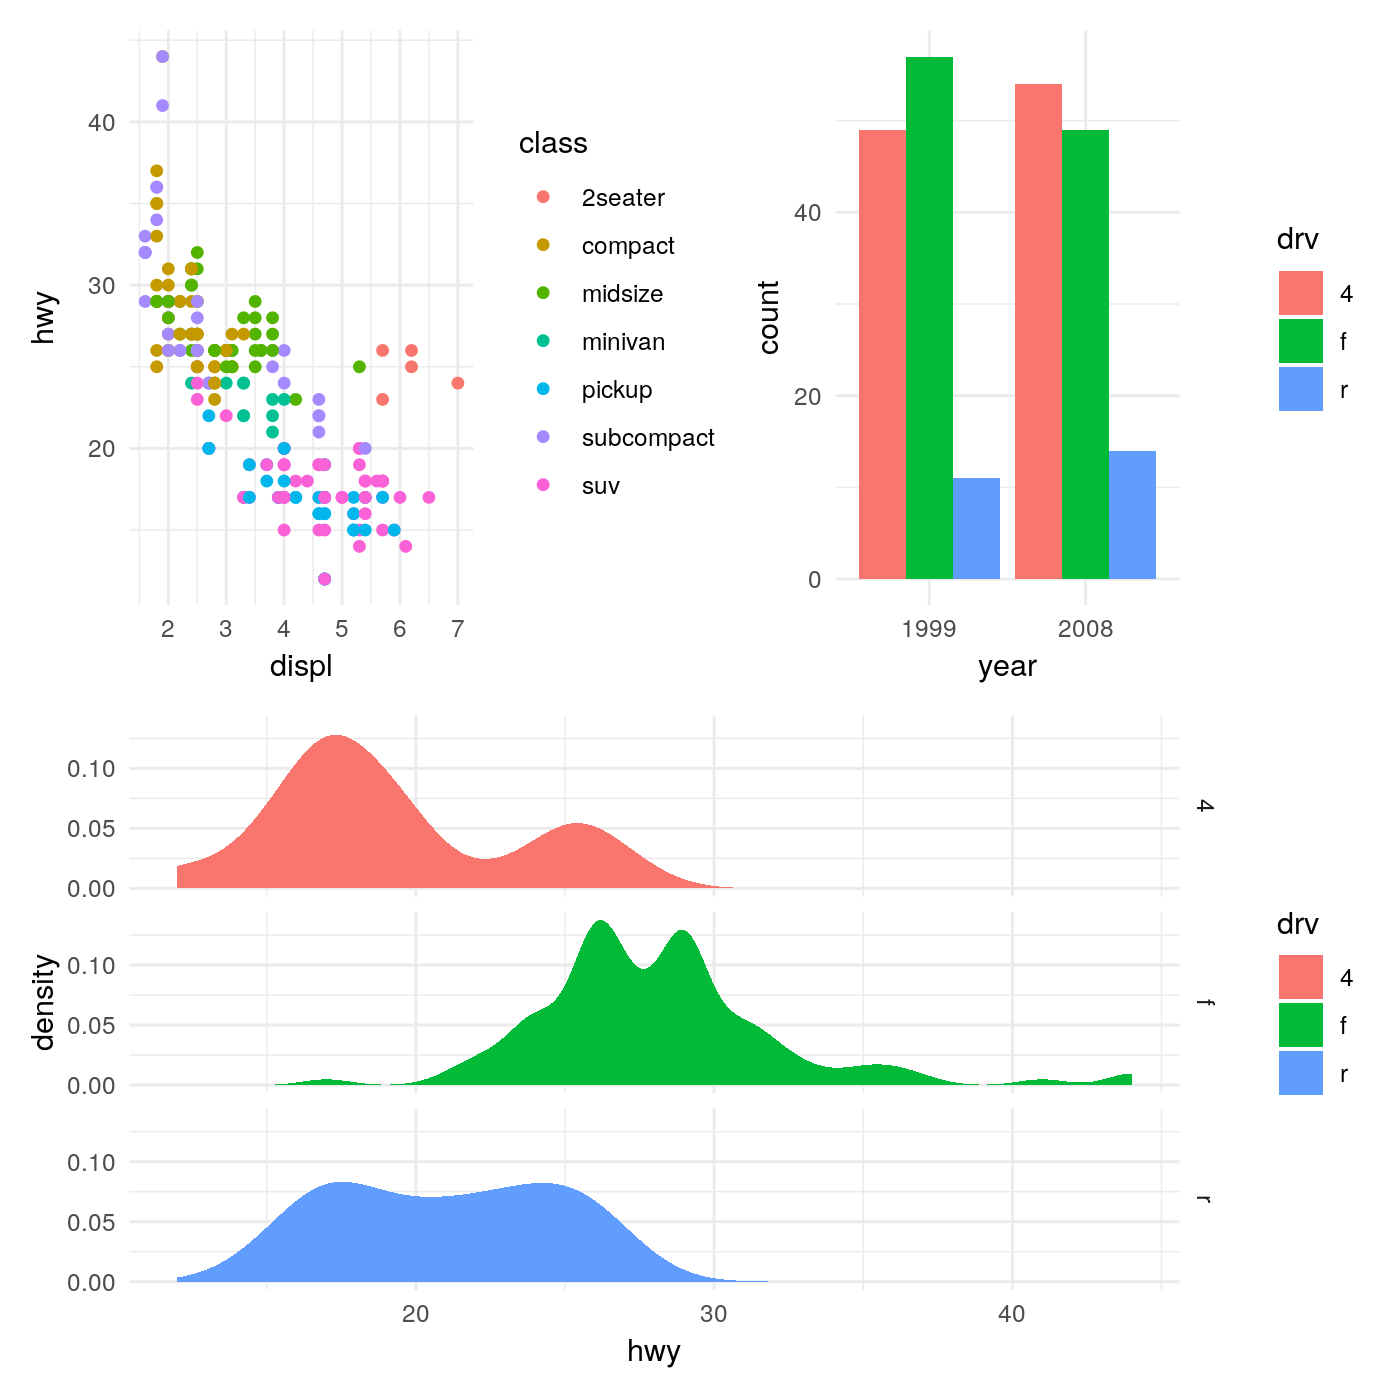

In [149]:
p <- (p1 + p2) / p3 
p[[2]] <- p[[2]] + theme_light()
p & theme_minimal()

`-` 모든서브플랏의 y축범위변경 

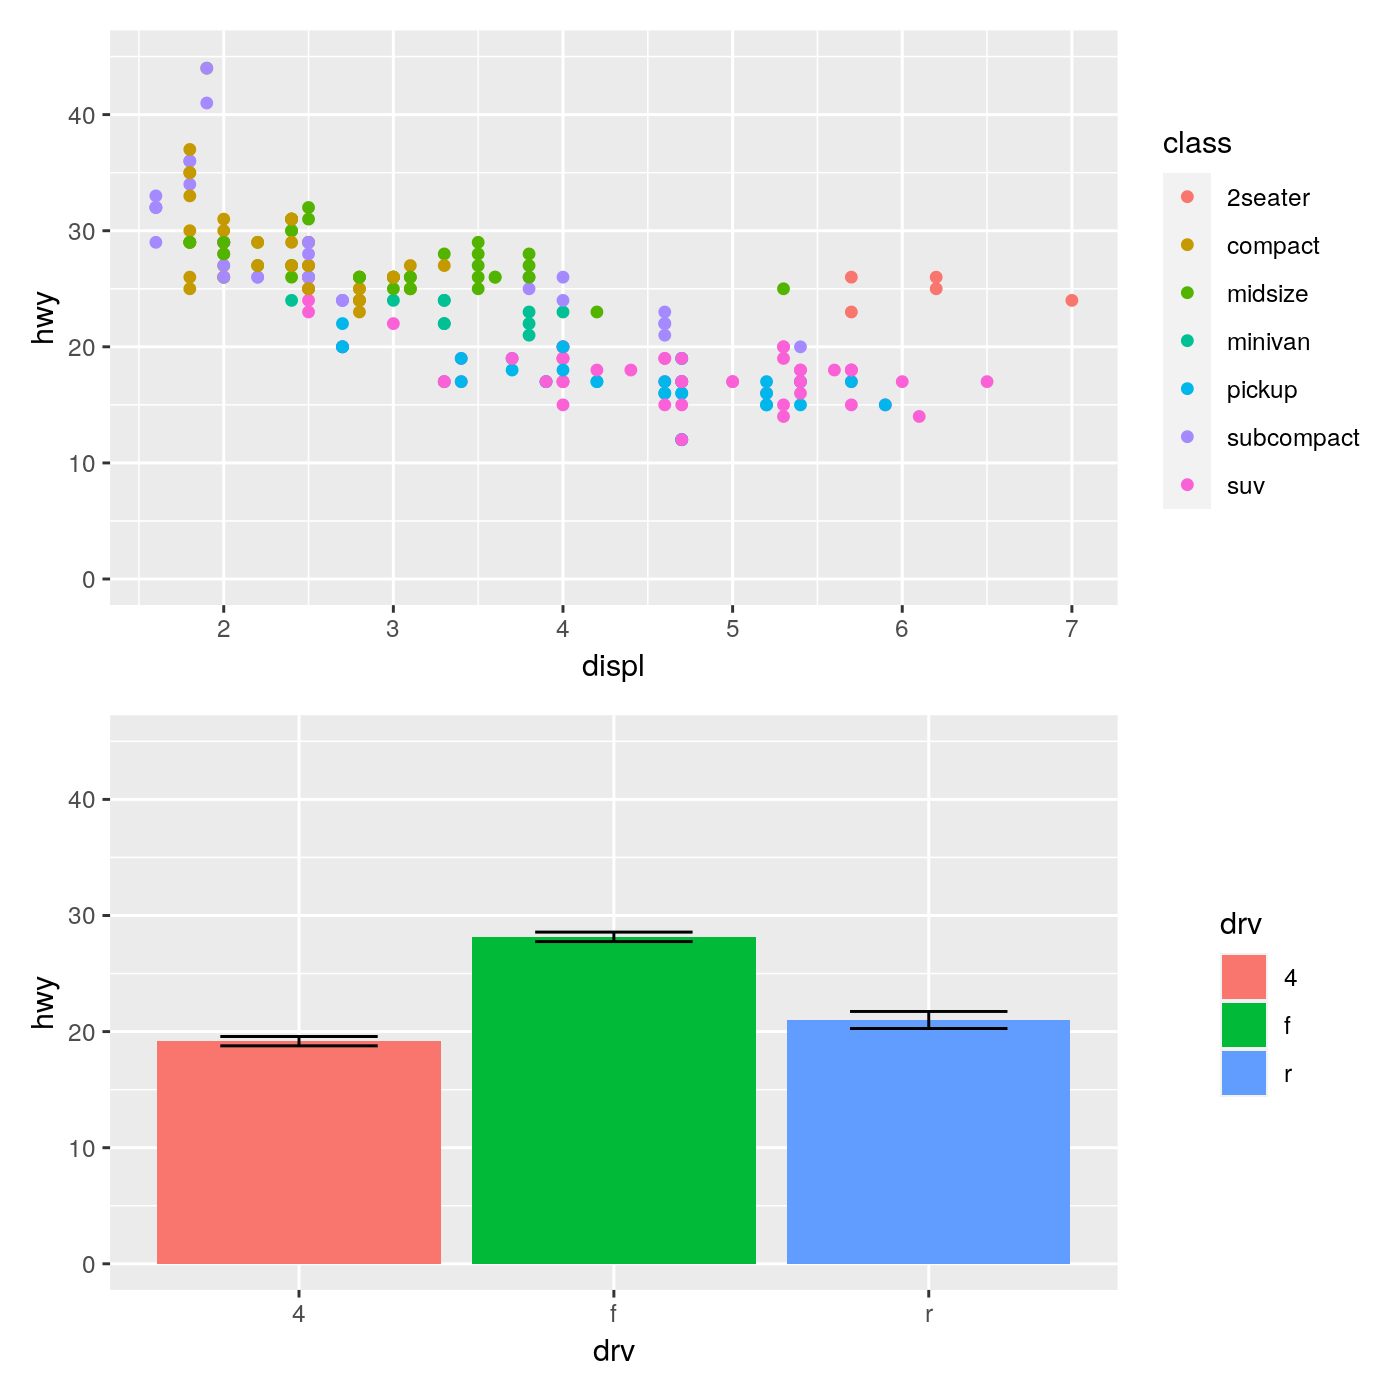

In [164]:
p = p1 / p4
p & scale_y_continuous(limits = c(0, 45))

### super-title, sub-title, annotation 

`-` p1~p4 정의 

In [165]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy, color = class))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` supertitle, annotation 

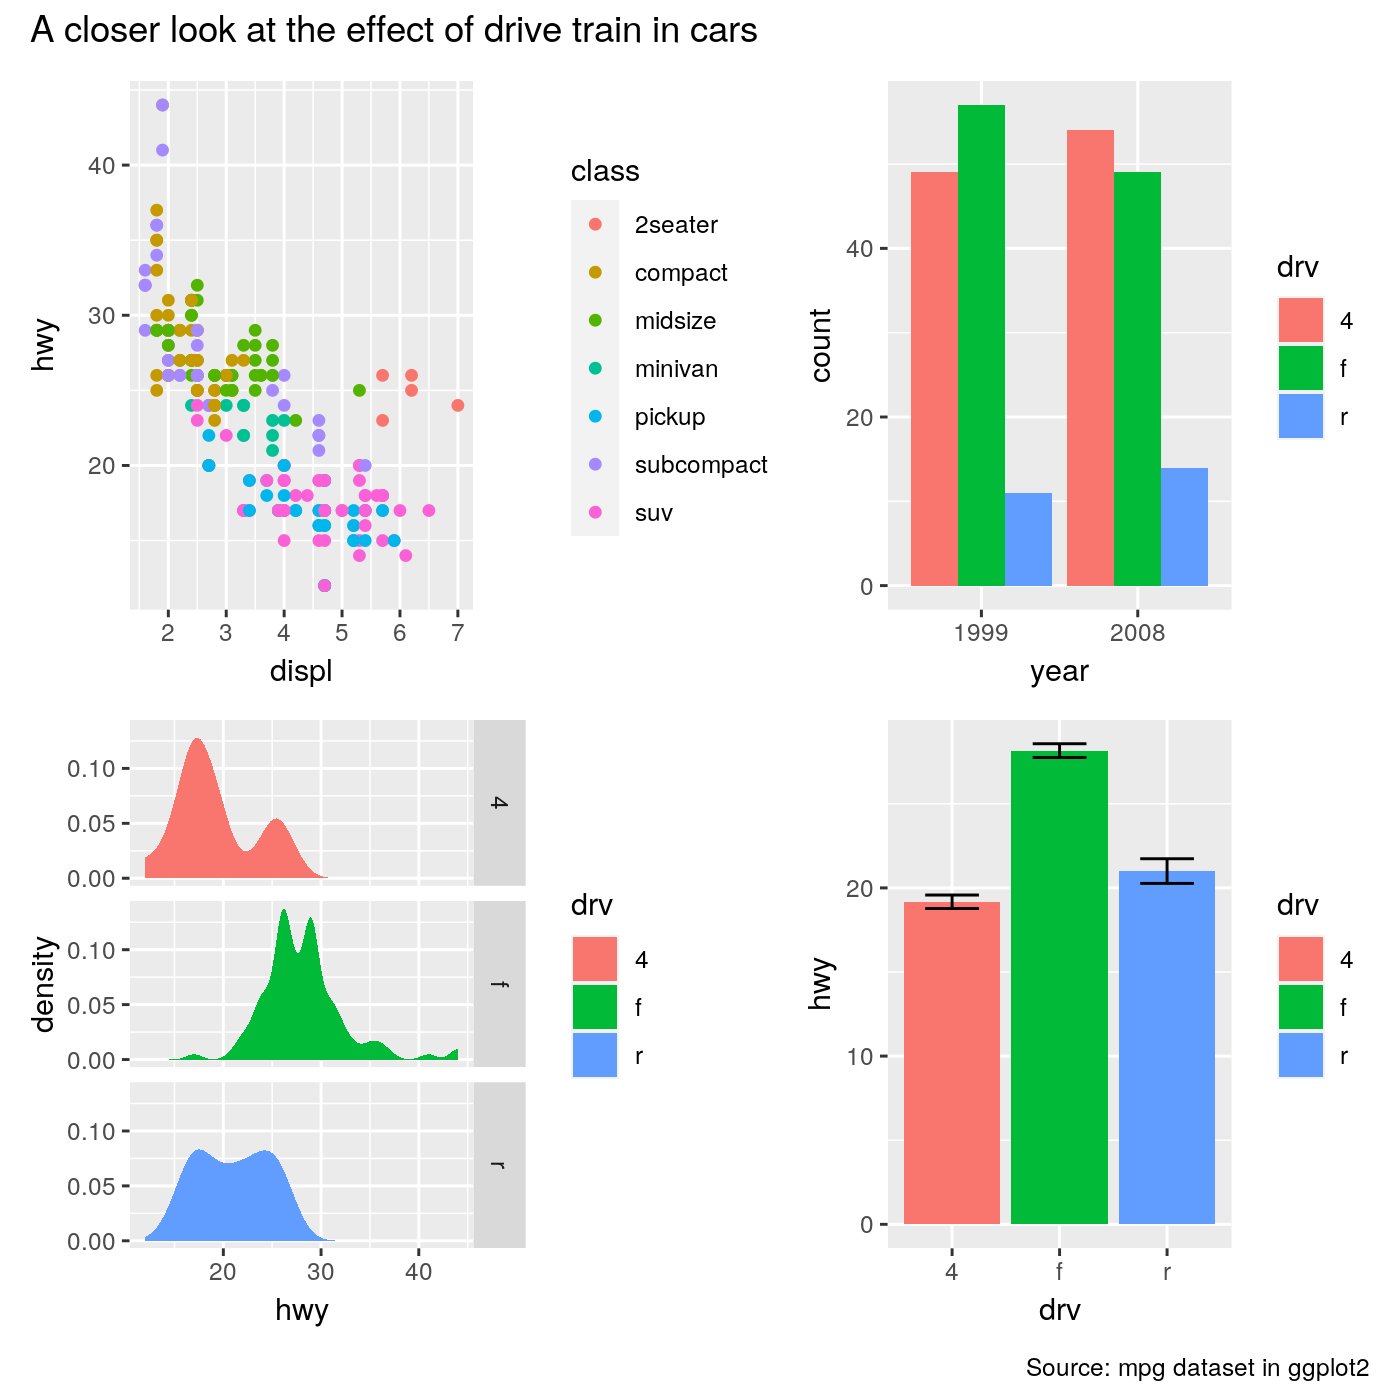

In [175]:
p <- p1 + p2 + p3 + p4 + plot_annotation(
  title = "A closer look at the effect of drive train in cars",
  caption = "Source: mpg dataset in ggplot2"
)
p

`-` 글씨체변경 (1)

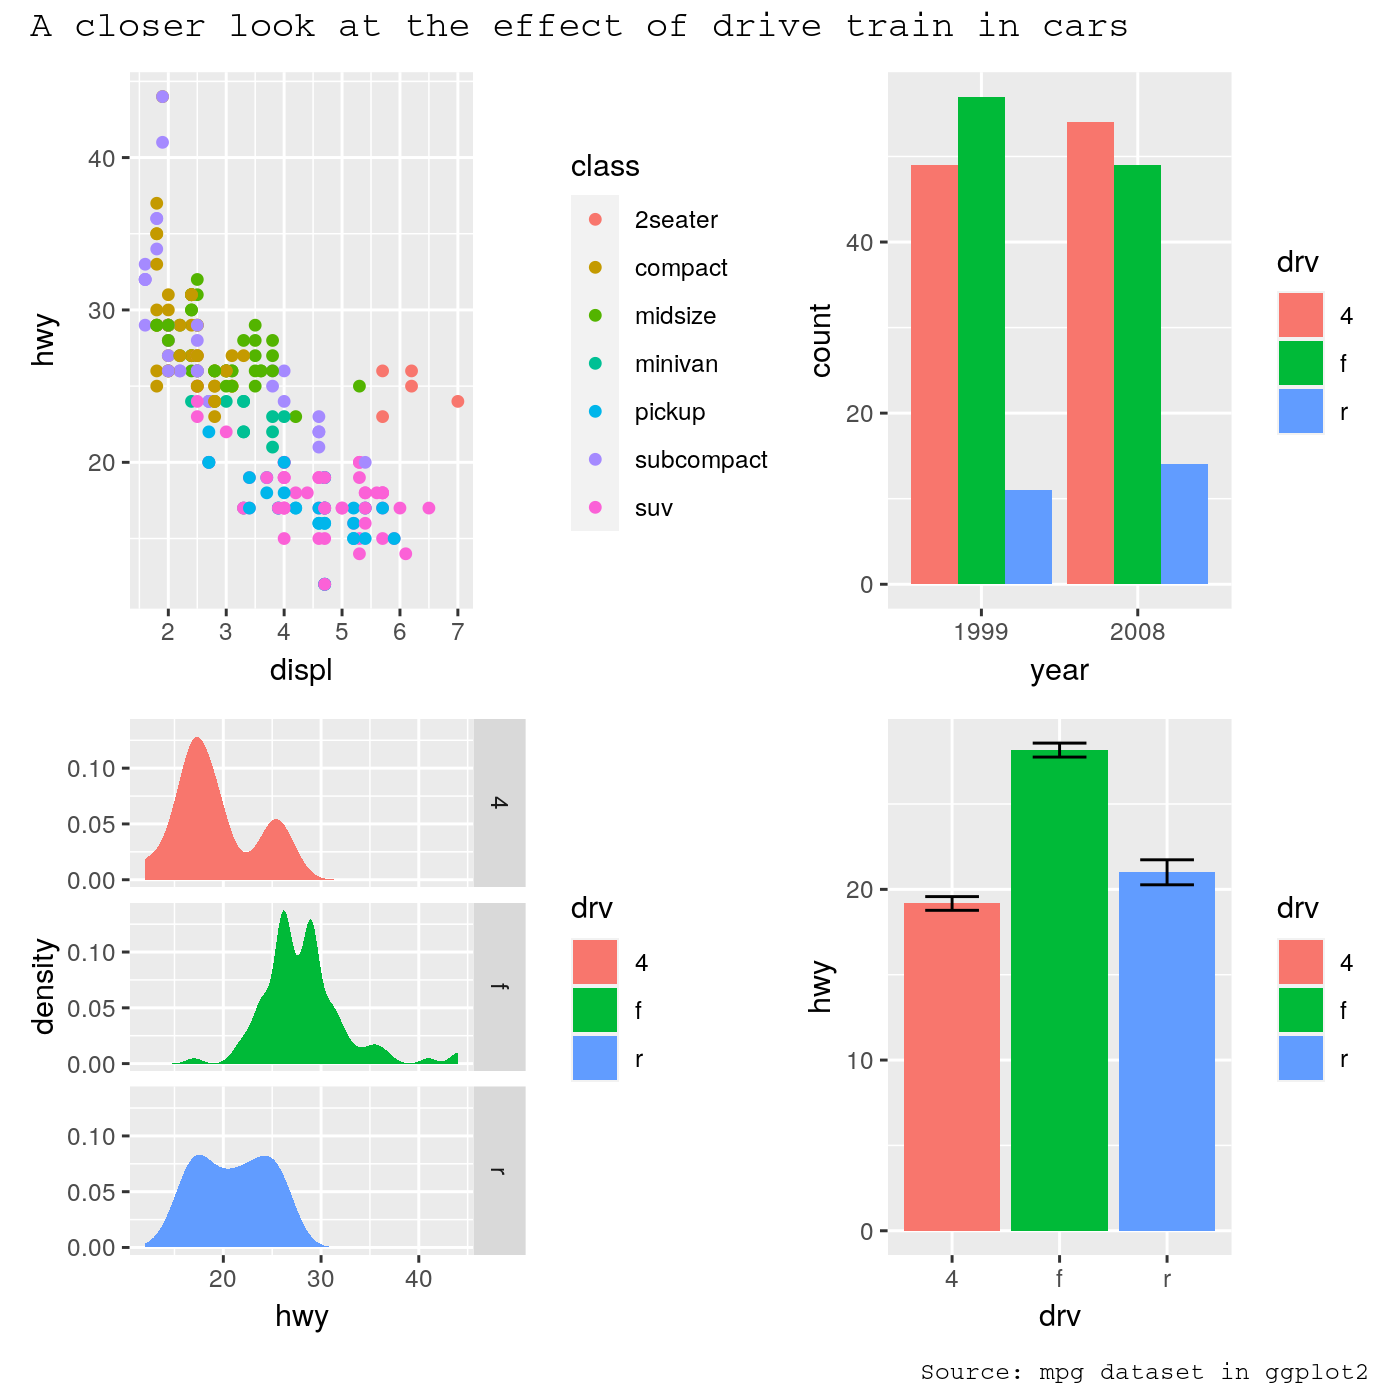

In [176]:
p <- p1 + p2 + p3 + p4 + plot_annotation(
  title = "A closer look at the effect of drive train in cars",
  caption = "Source: mpg dataset in ggplot2",
  theme = theme_gray(base_family = "mono")  ### 이걸 추가하면 글씨체가 바뀐다.  
)
p

`-` 글씨체변경 (2)

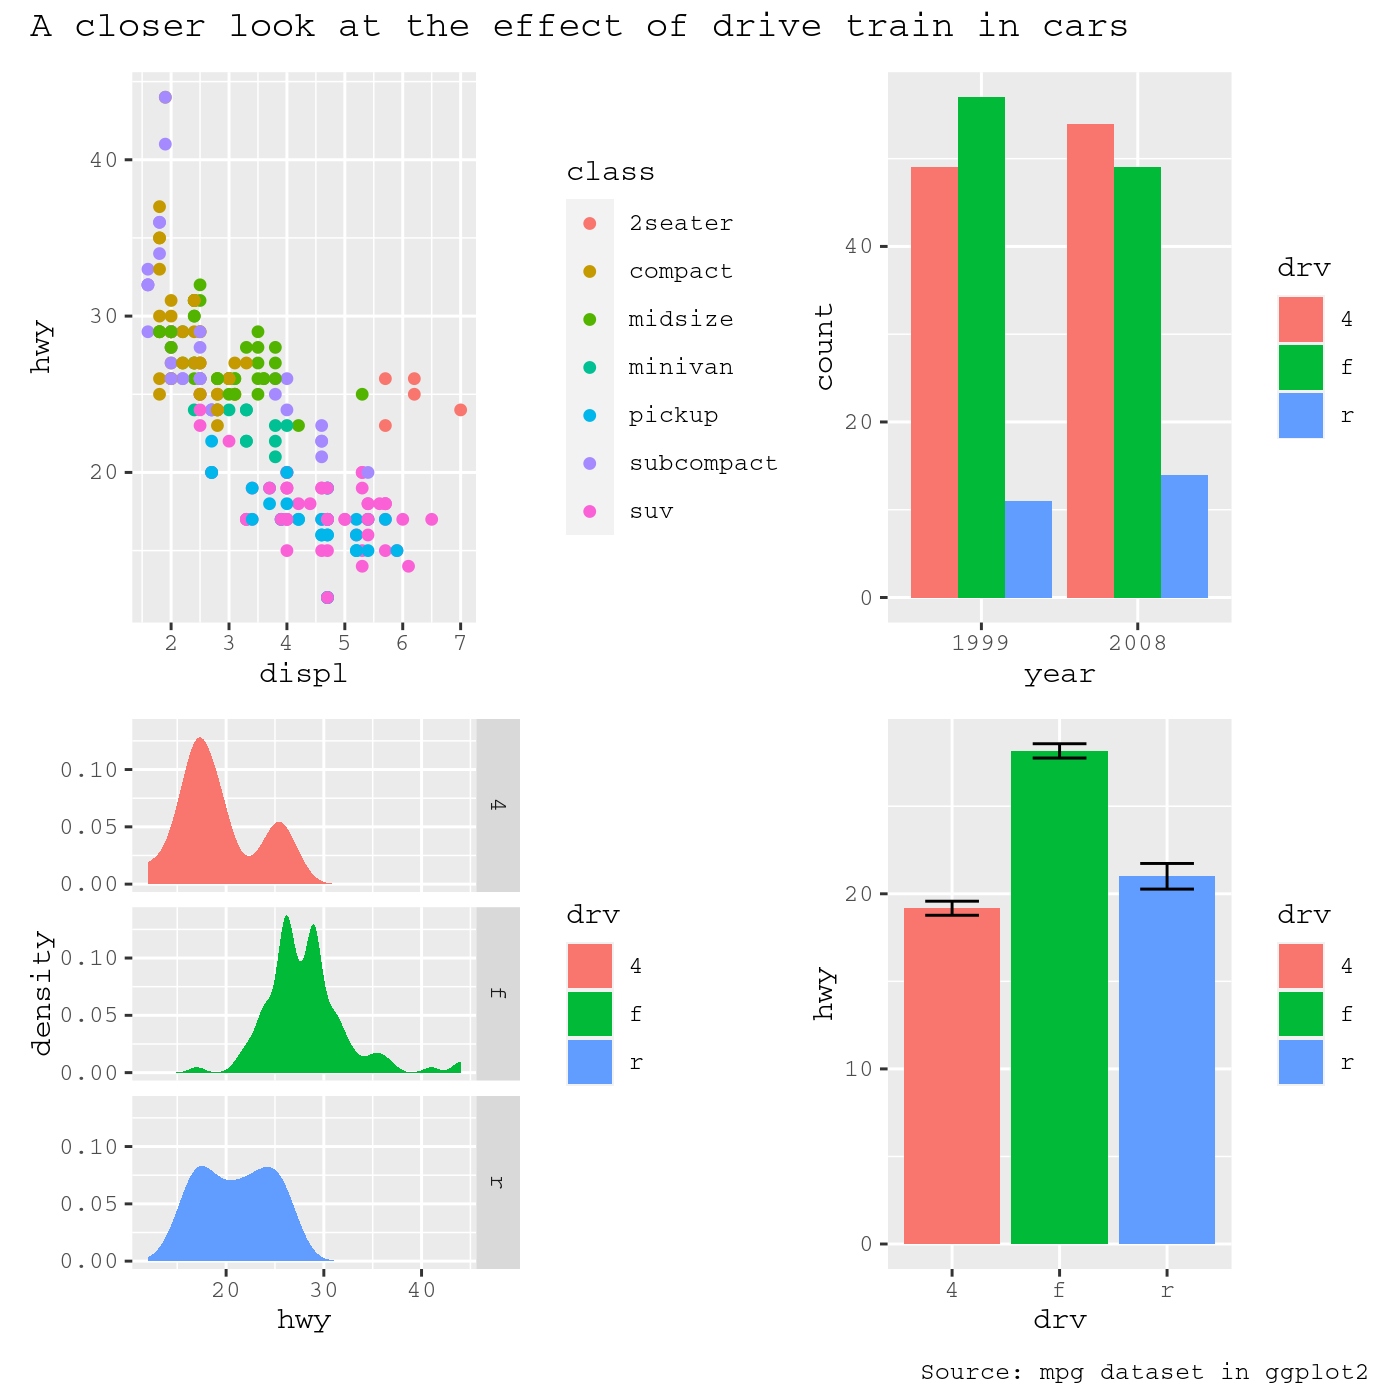

In [177]:
p <- p1 + p2 + p3 + p4 + plot_annotation(
  title = "A closer look at the effect of drive train in cars",
  caption = "Source: mpg dataset in ggplot2"
)
p & theme_gray(base_family = "mono") 
## p + theme_gray(base_family = "mono") 는 동작하지 않음 

#### sub-title 

`-` p1~p4 정의 

In [165]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy, color = class))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` 그림준비 

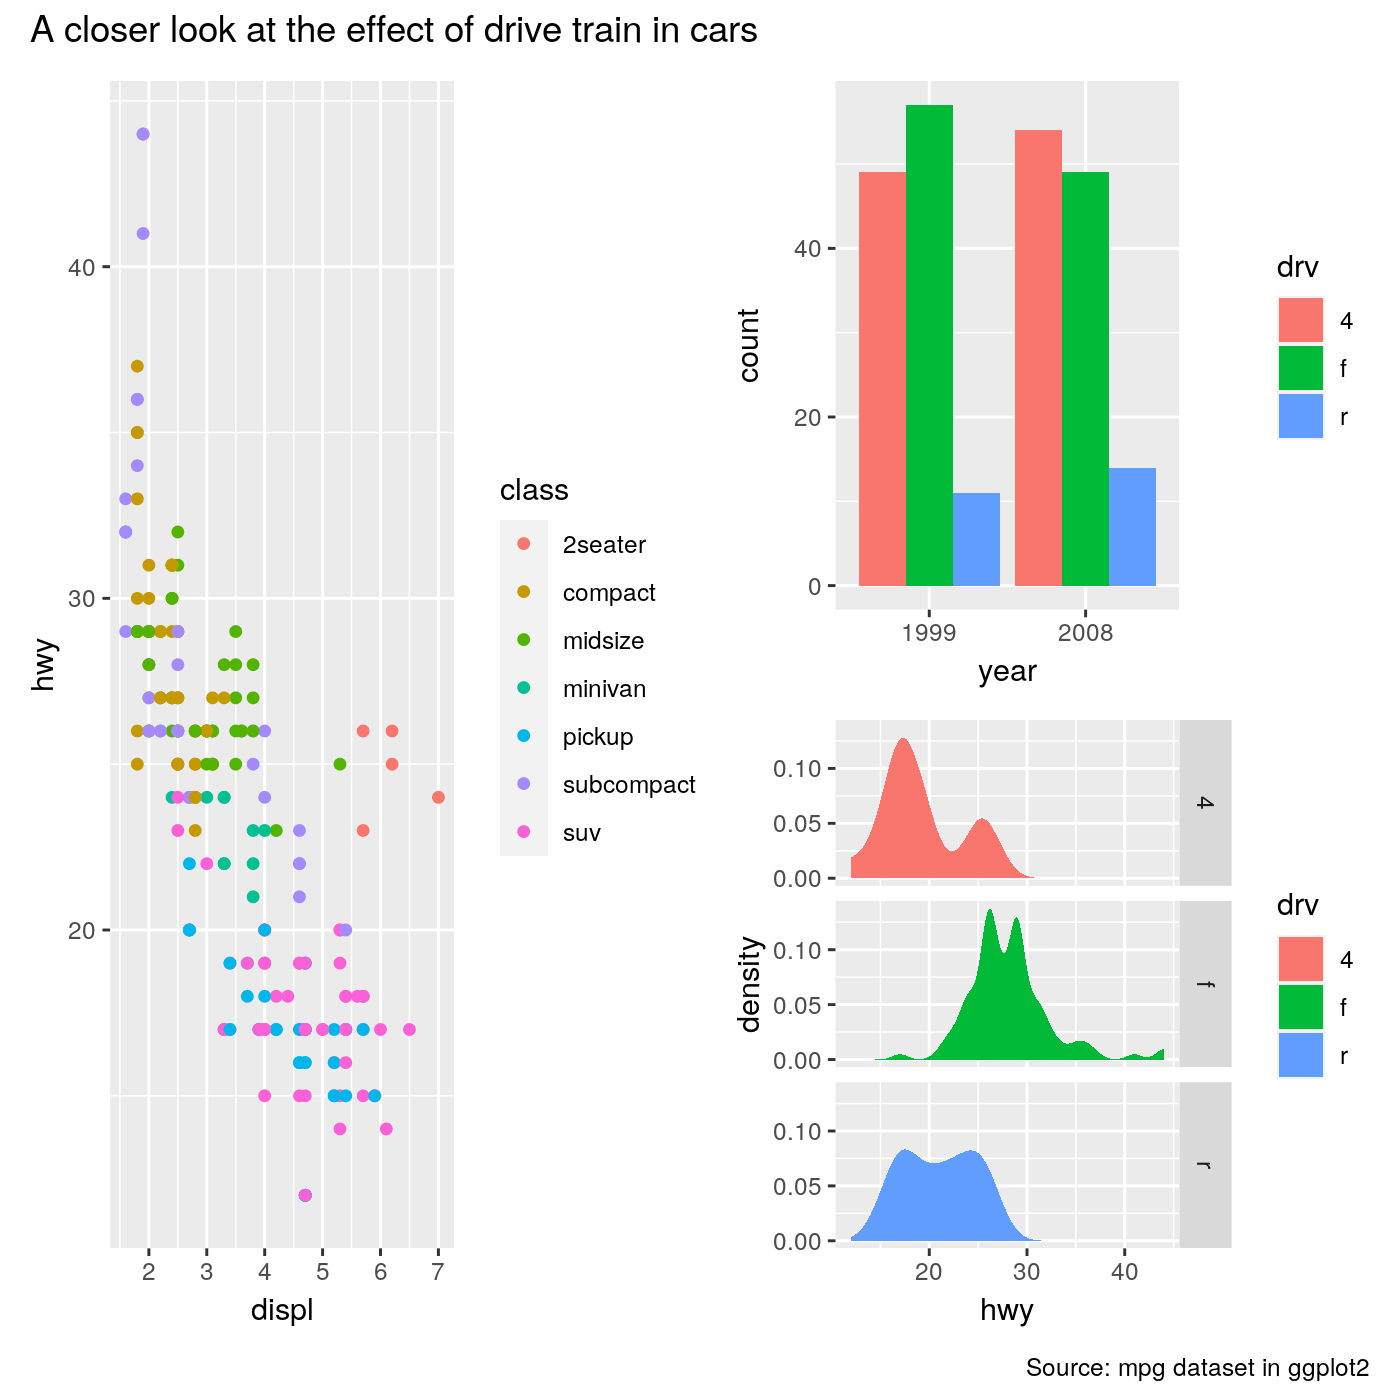

In [188]:
p <- (p1 | (p2/p3)) + plot_annotation(
  title = "A closer look at the effect of drive train in cars",
  caption = "Source: mpg dataset in ggplot2"
)
p

`-` p[[1]], p[[2]] 확인 

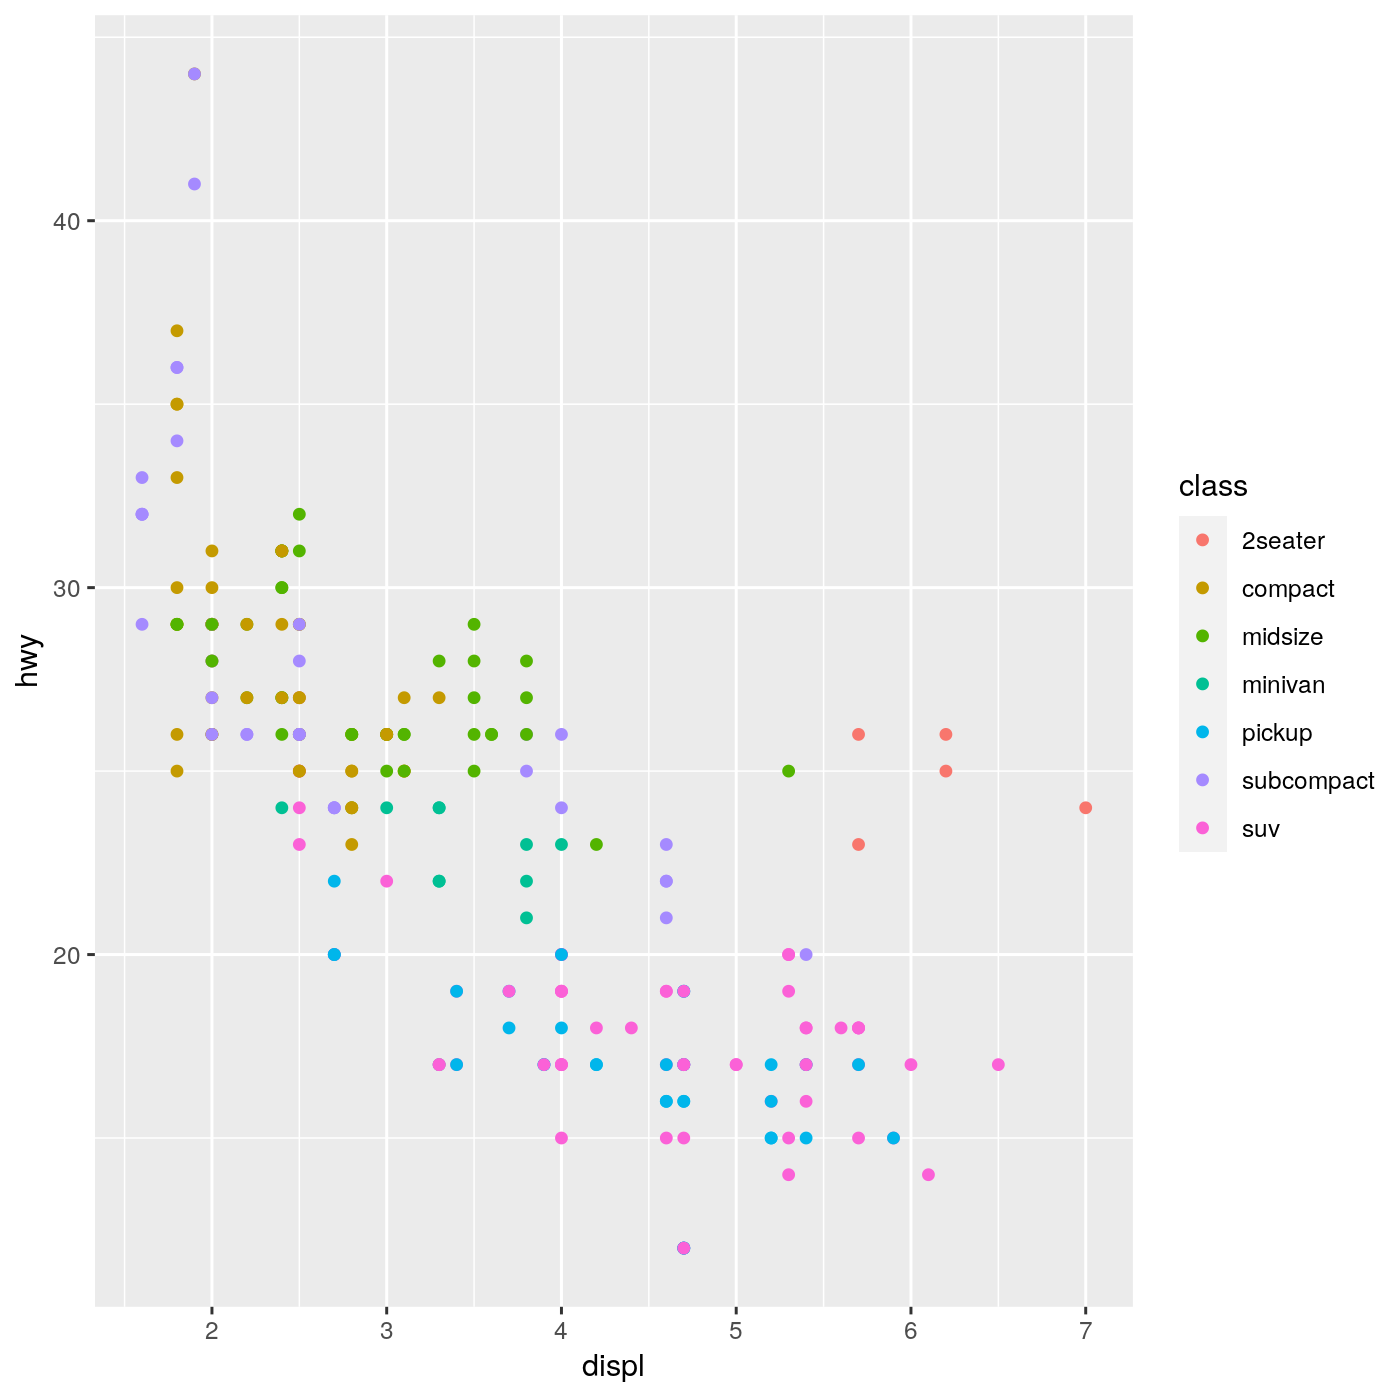

In [190]:
p[[1]]

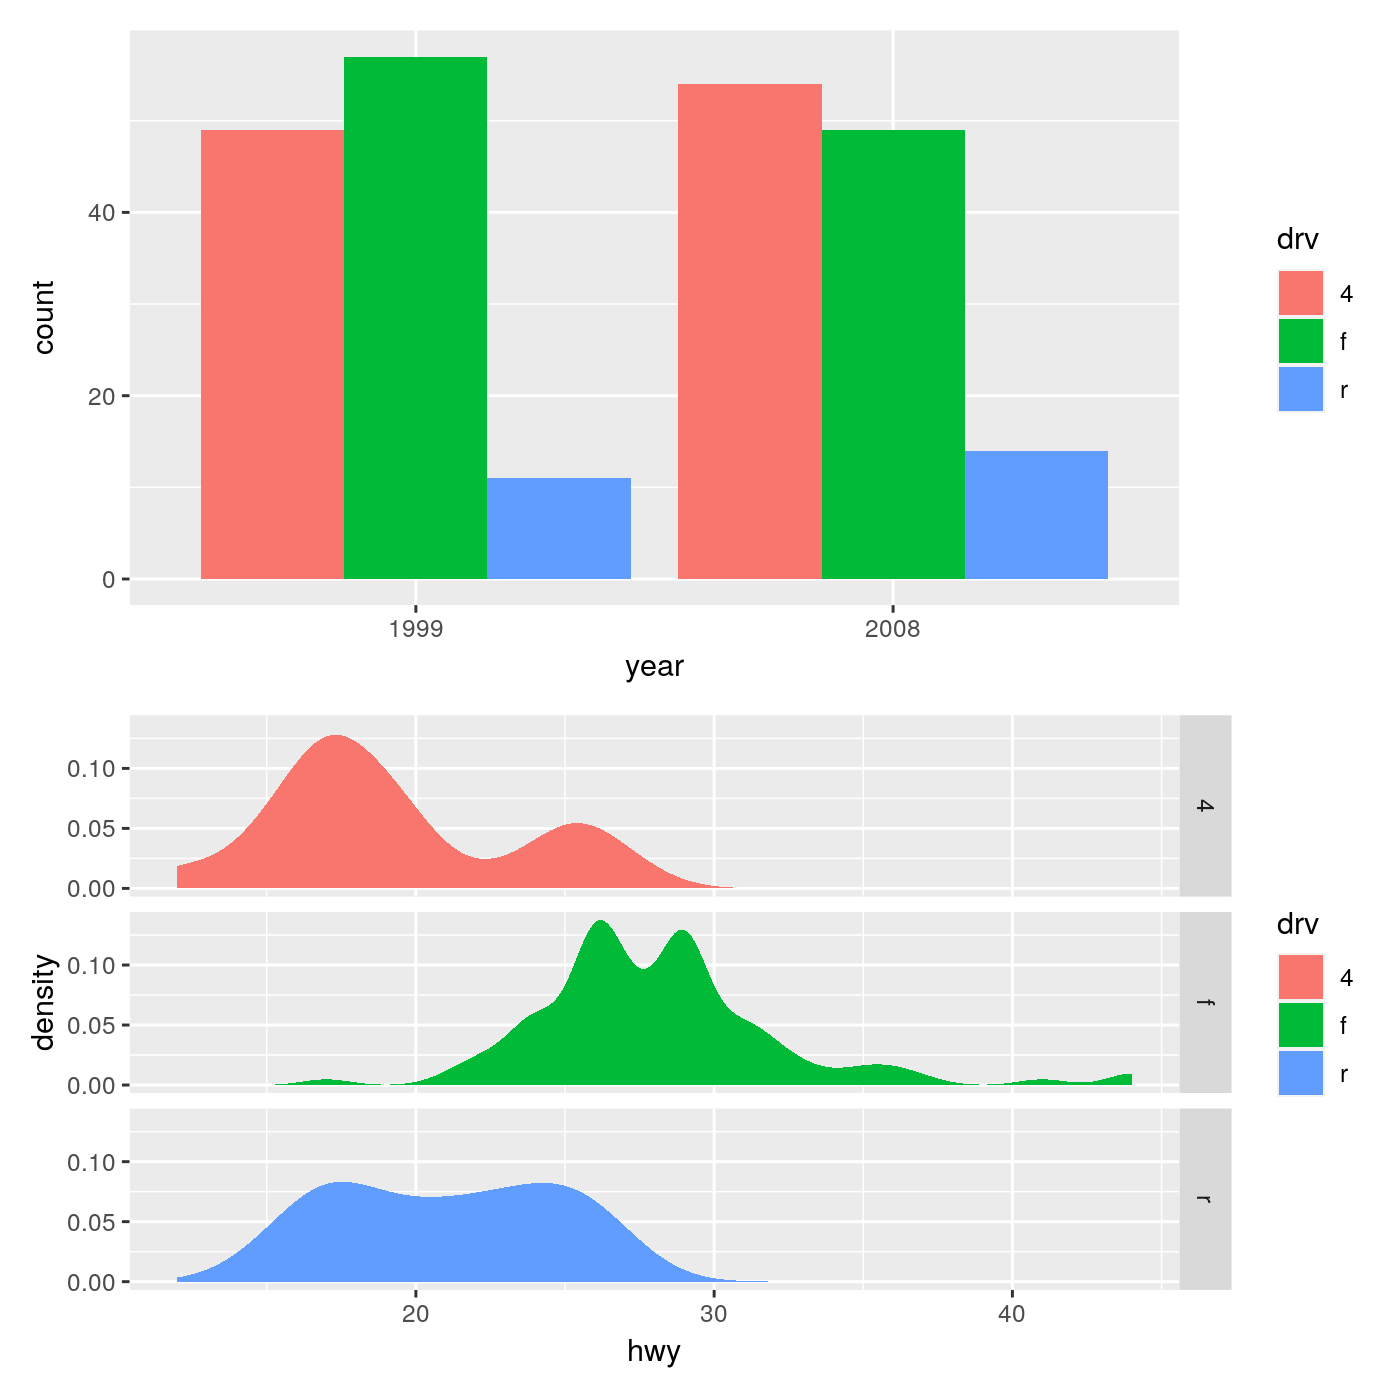

In [191]:
p[[2]]

`-` tag_levels로 subtitle 만듬

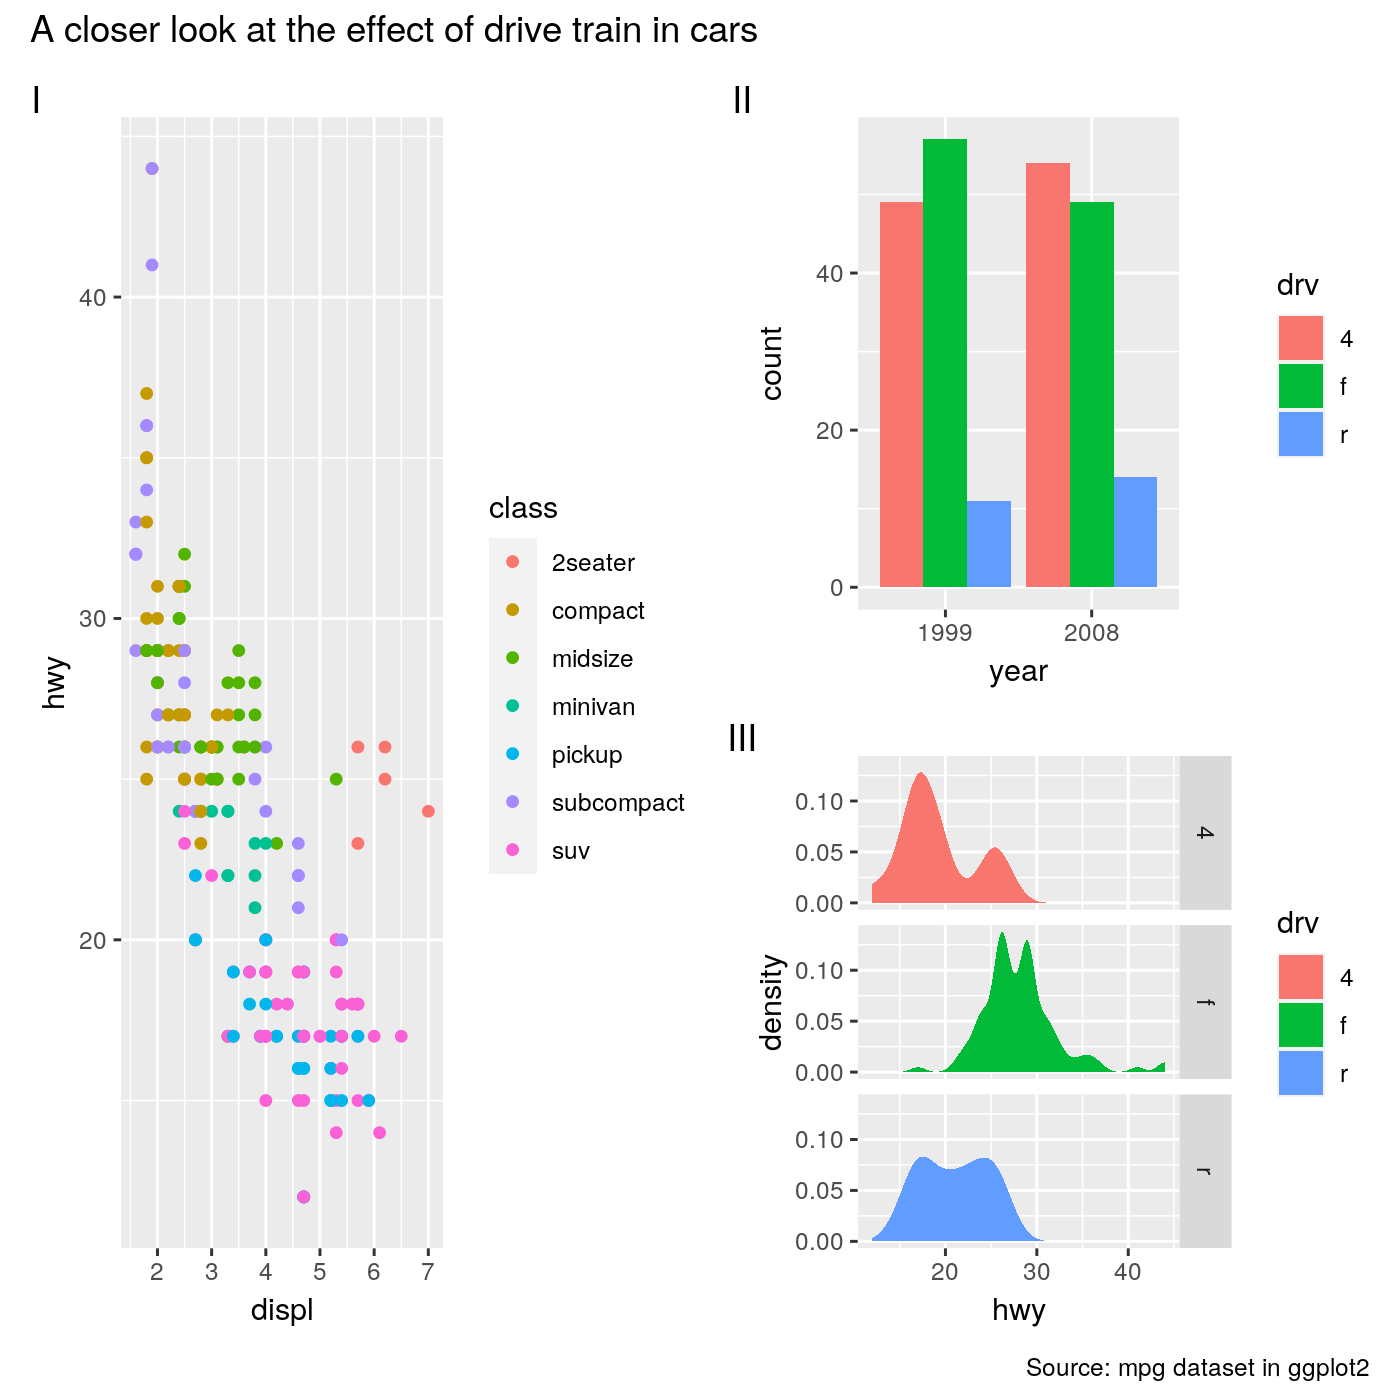

In [193]:
p+plot_annotation(tag_levels = c("I"))

`-` tag_levels를 2단계로 함 

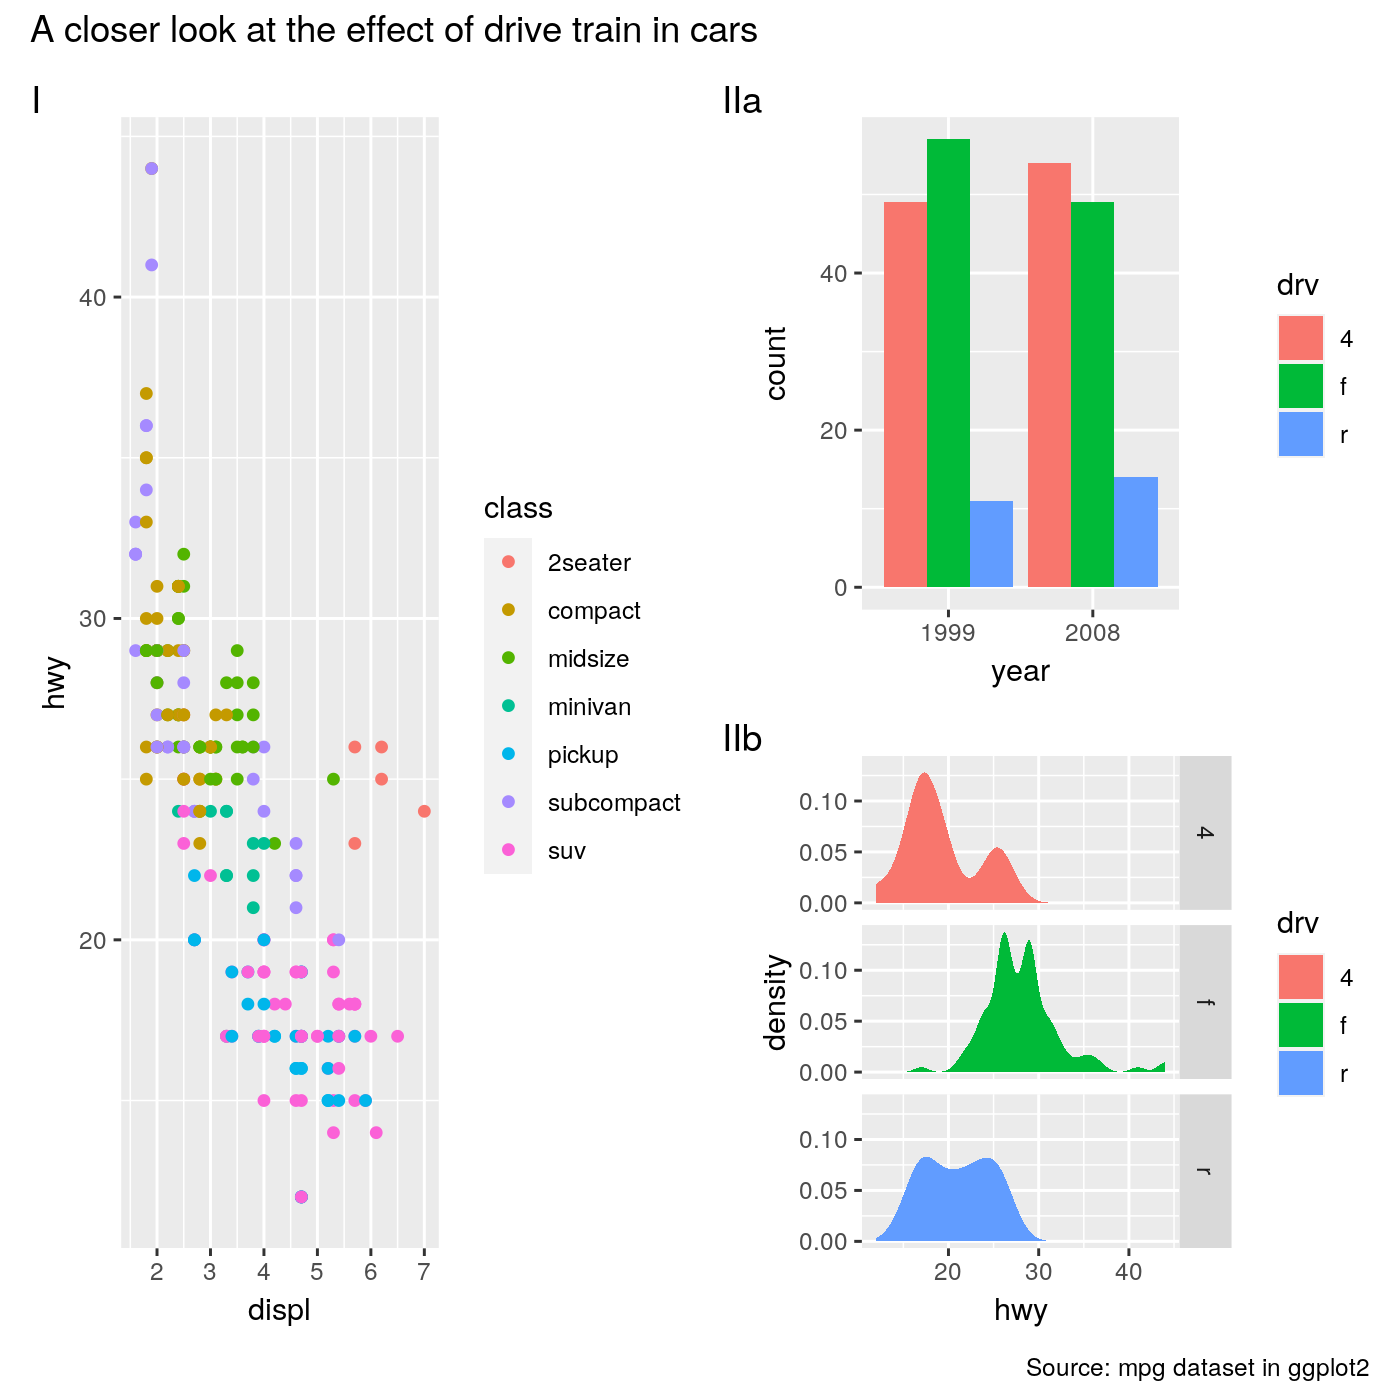

In [196]:
p[[2]] <- p[[2]] + plot_layout(tag_level = "new")
p+plot_annotation(tag_levels = c("I","a"))

- 별로 유용한지 모르겠음 

### plot 삽입 

`-` p1~p4 정의 

In [165]:
p1 <- ggplot(mpg) + 
  geom_point(aes(x = displ, y = hwy, color = class))

p2 <- ggplot(mpg) + 
  geom_bar(aes(x = as.character(year), fill = drv), position = "dodge") + 
  labs(x = "year")

p3 <- ggplot(mpg) + 
  geom_density(aes(x = hwy, fill = drv), colour = NA) + 
  facet_grid(rows = vars(drv))

p4 <- ggplot(mpg) + 
  stat_summary(aes(x = drv, y = hwy, fill = drv), geom = "col", fun.data = mean_se) +
  stat_summary(aes(x = drv, y = hwy), geom = "errorbar", fun.data = mean_se, width = 0.5)

`-` 그림삽입1

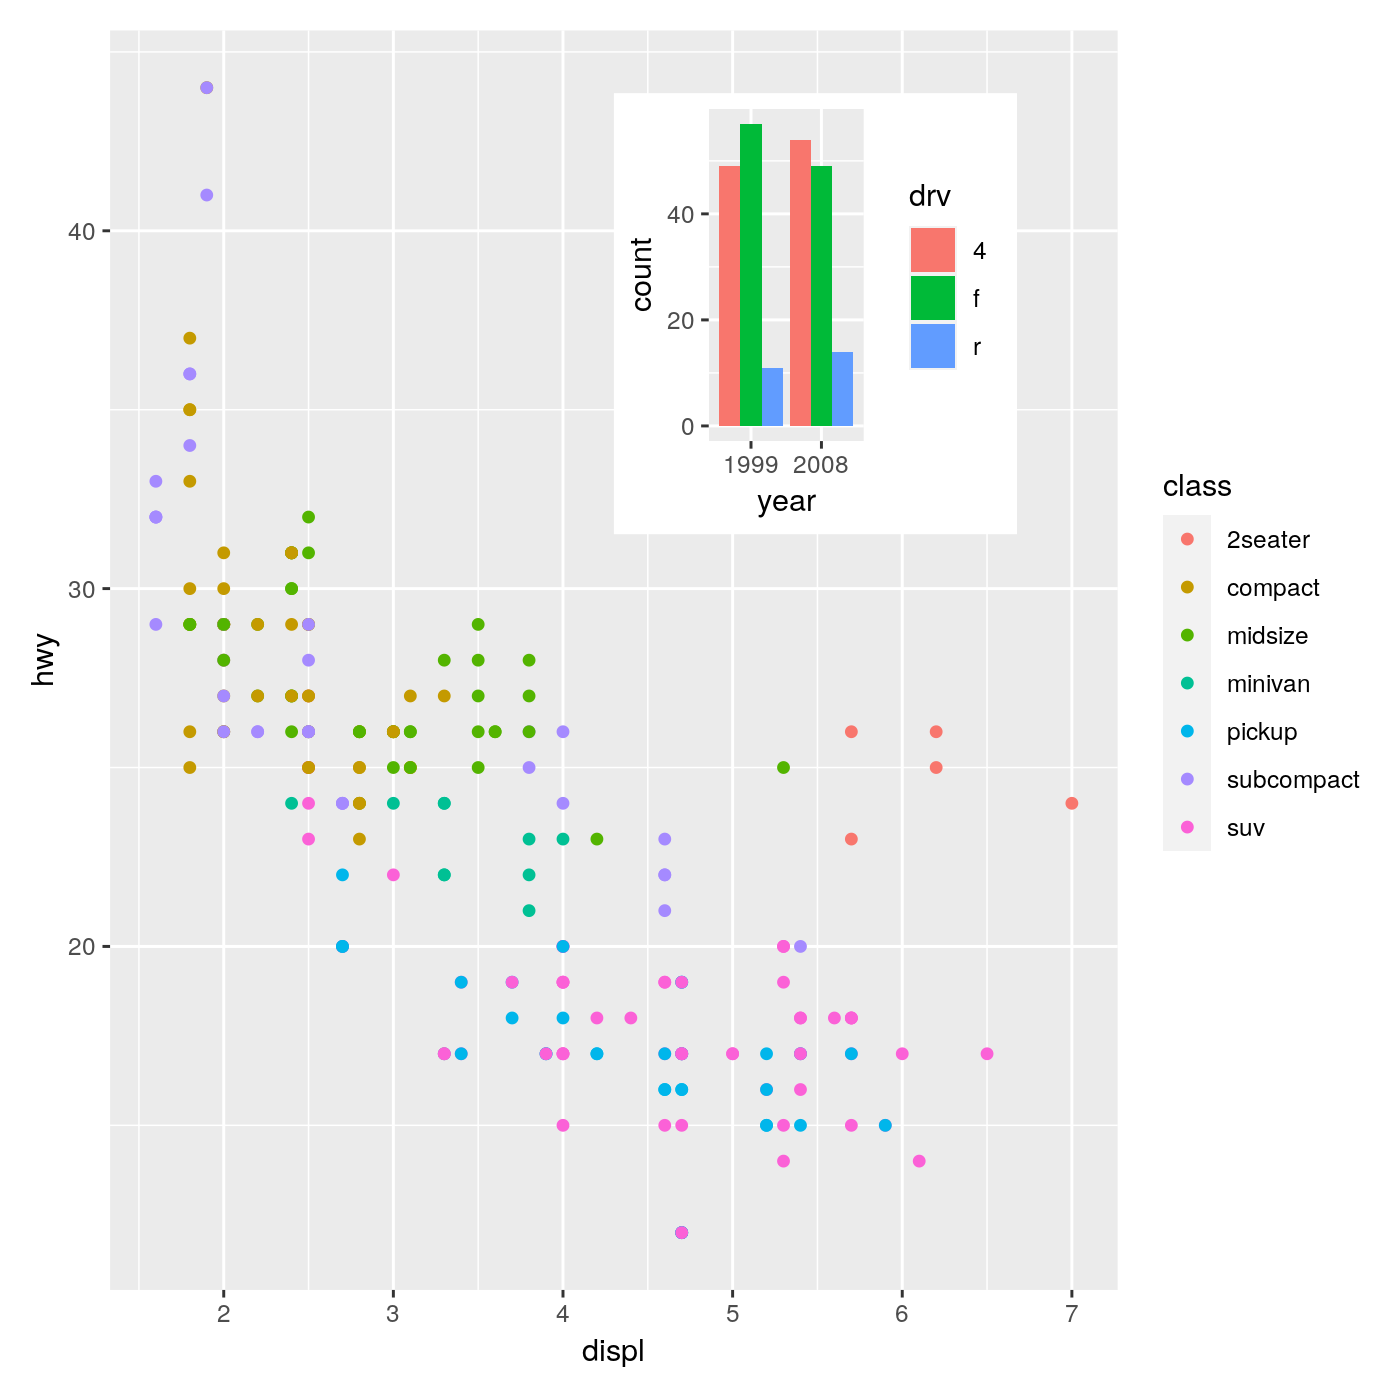

In [207]:
p1 + inset_element(p2, left = 0.5, bottom = 0.6, right = 0.9, top = 0.95)

`-` 그림삽입2

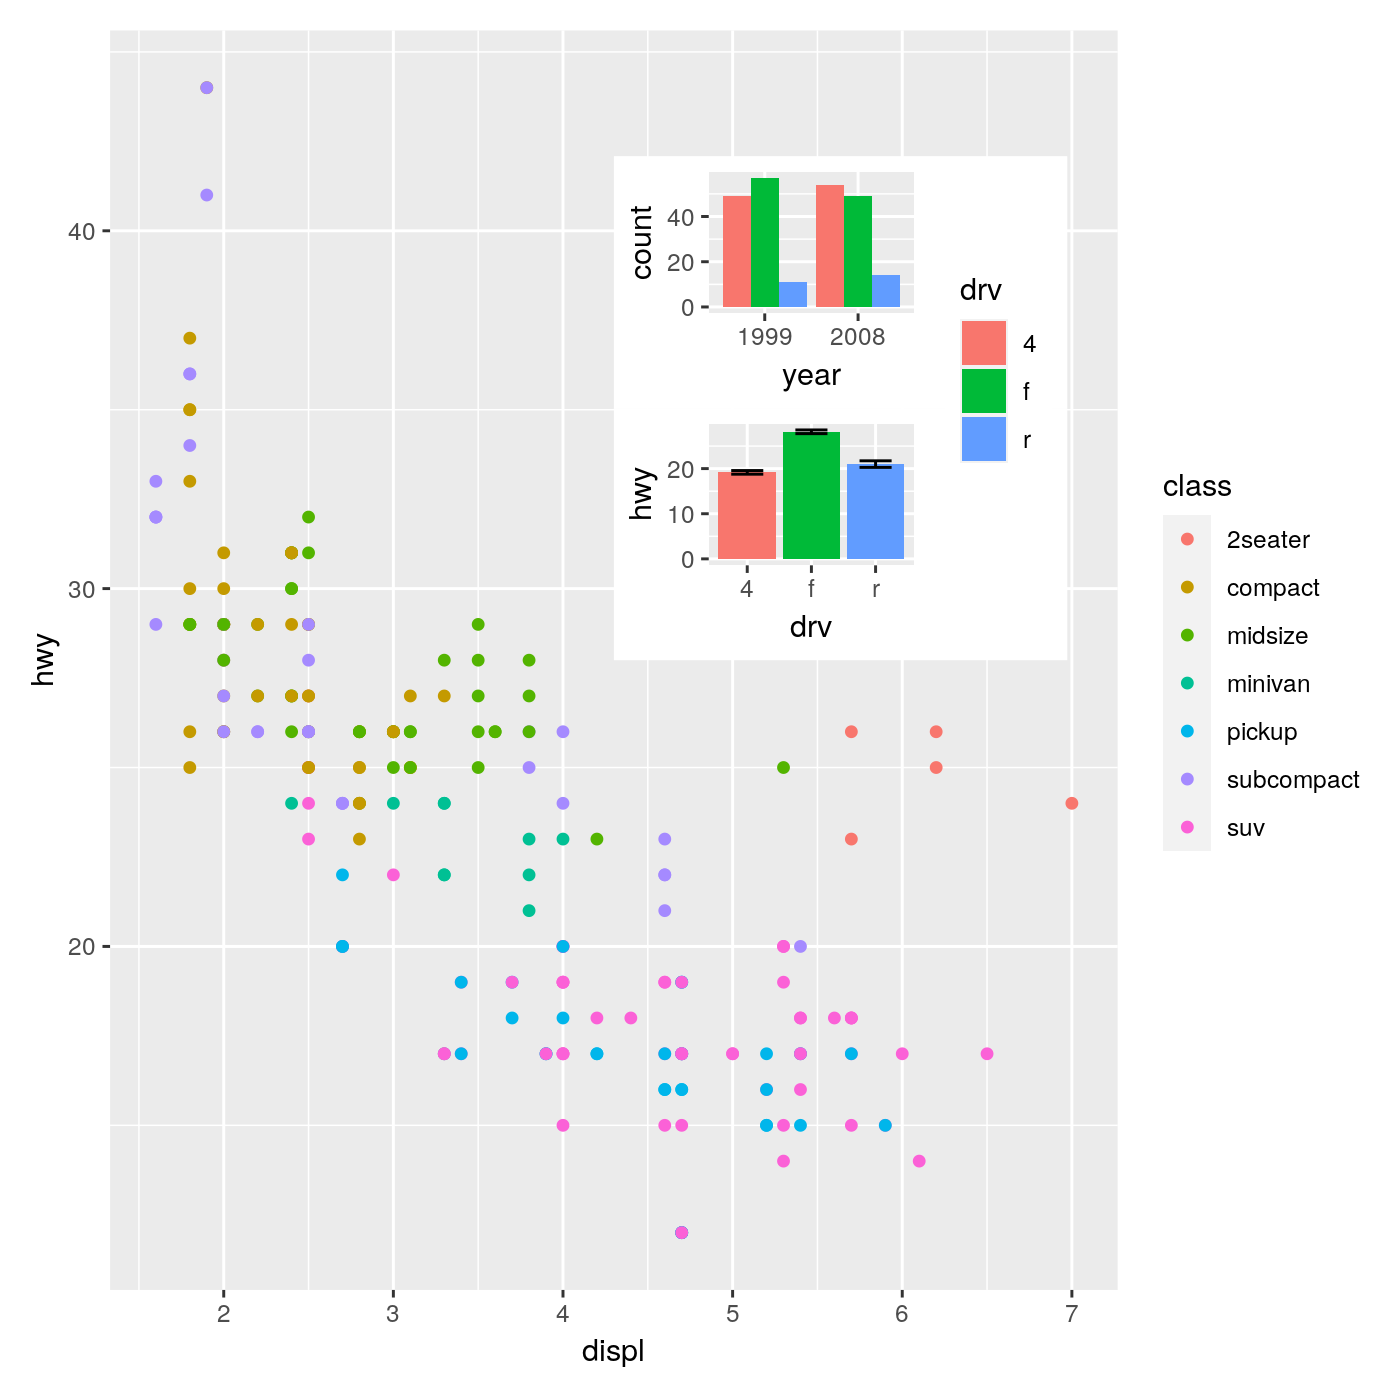

In [201]:
p24 <- p2 / p4 + plot_layout(guides = "collect")
p1 + inset_element(p24, left = 0.5, bottom = 0.5, right = 0.95, top = 0.9)

`-` 그림삽입3 

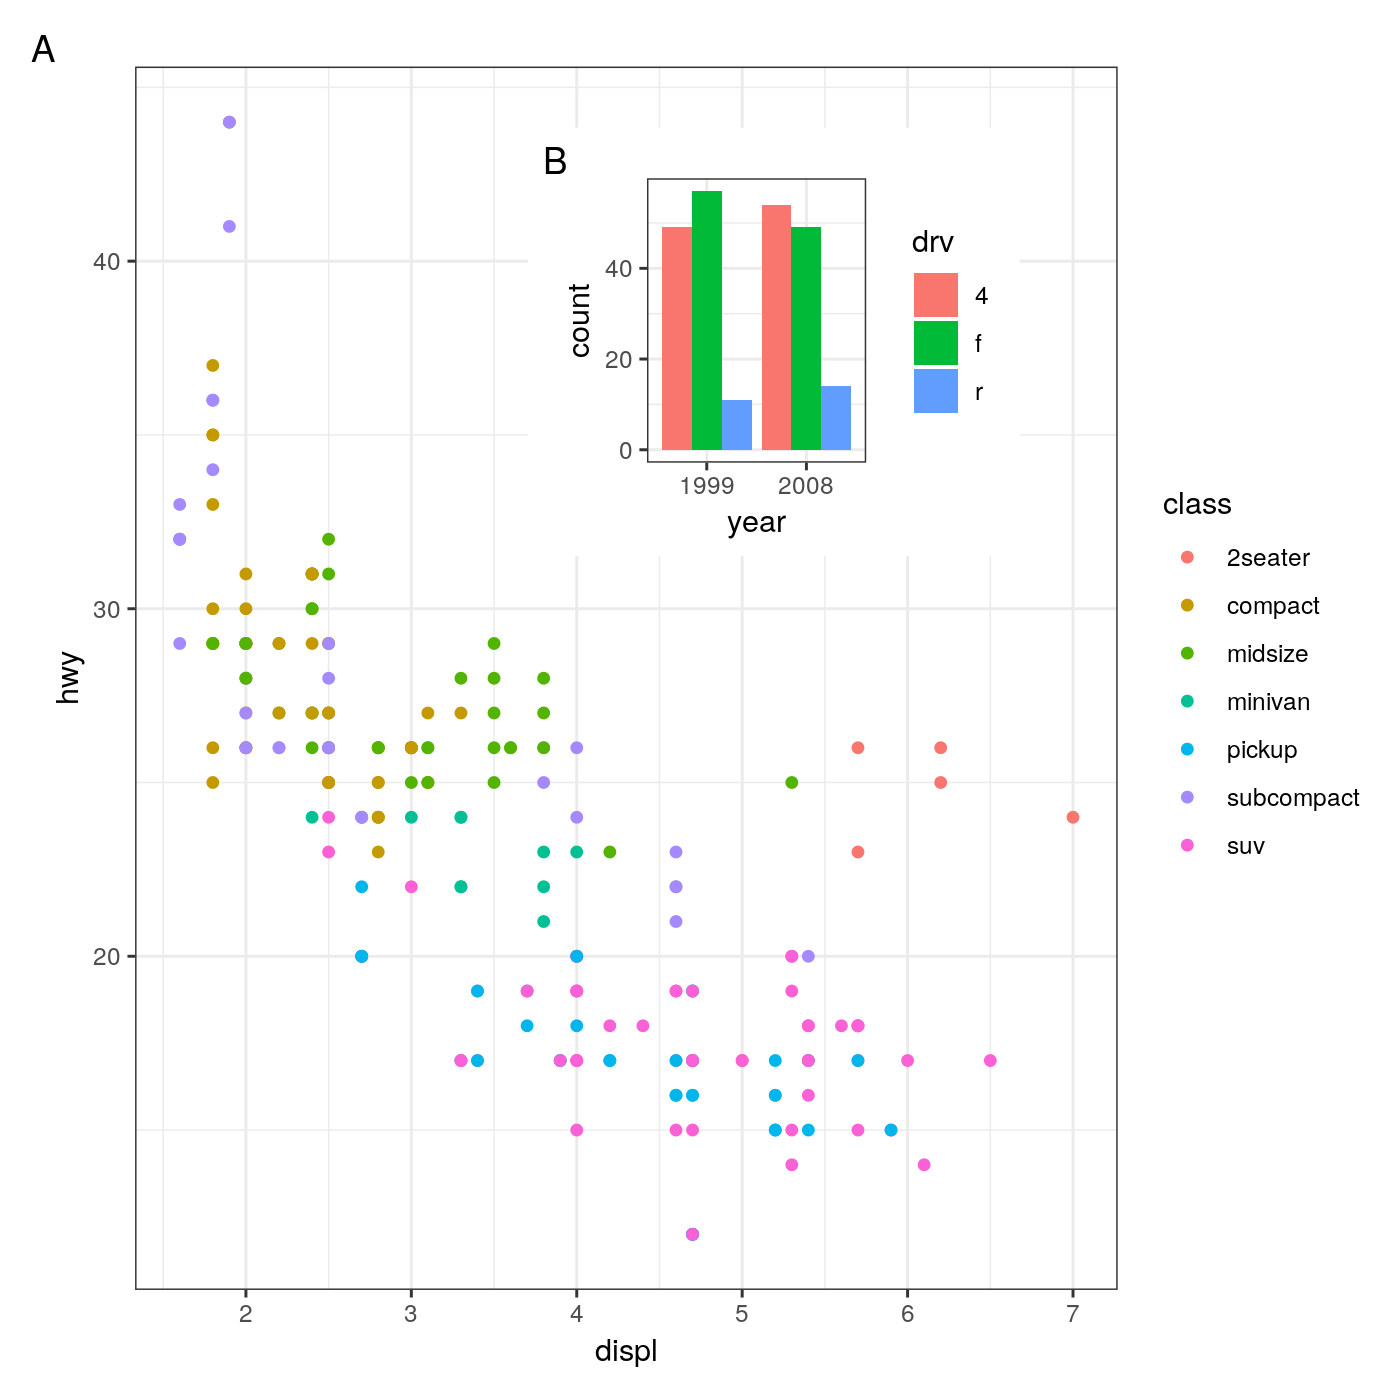

In [206]:
p12 <- p1 + inset_element(p2, left = 0.4, bottom = 0.6, right = 0.9, top = 0.95) +
  plot_annotation(tag_levels = 'A')
p12 & theme_bw() 

## 범례

### 범례제거

`-` 예제그림 

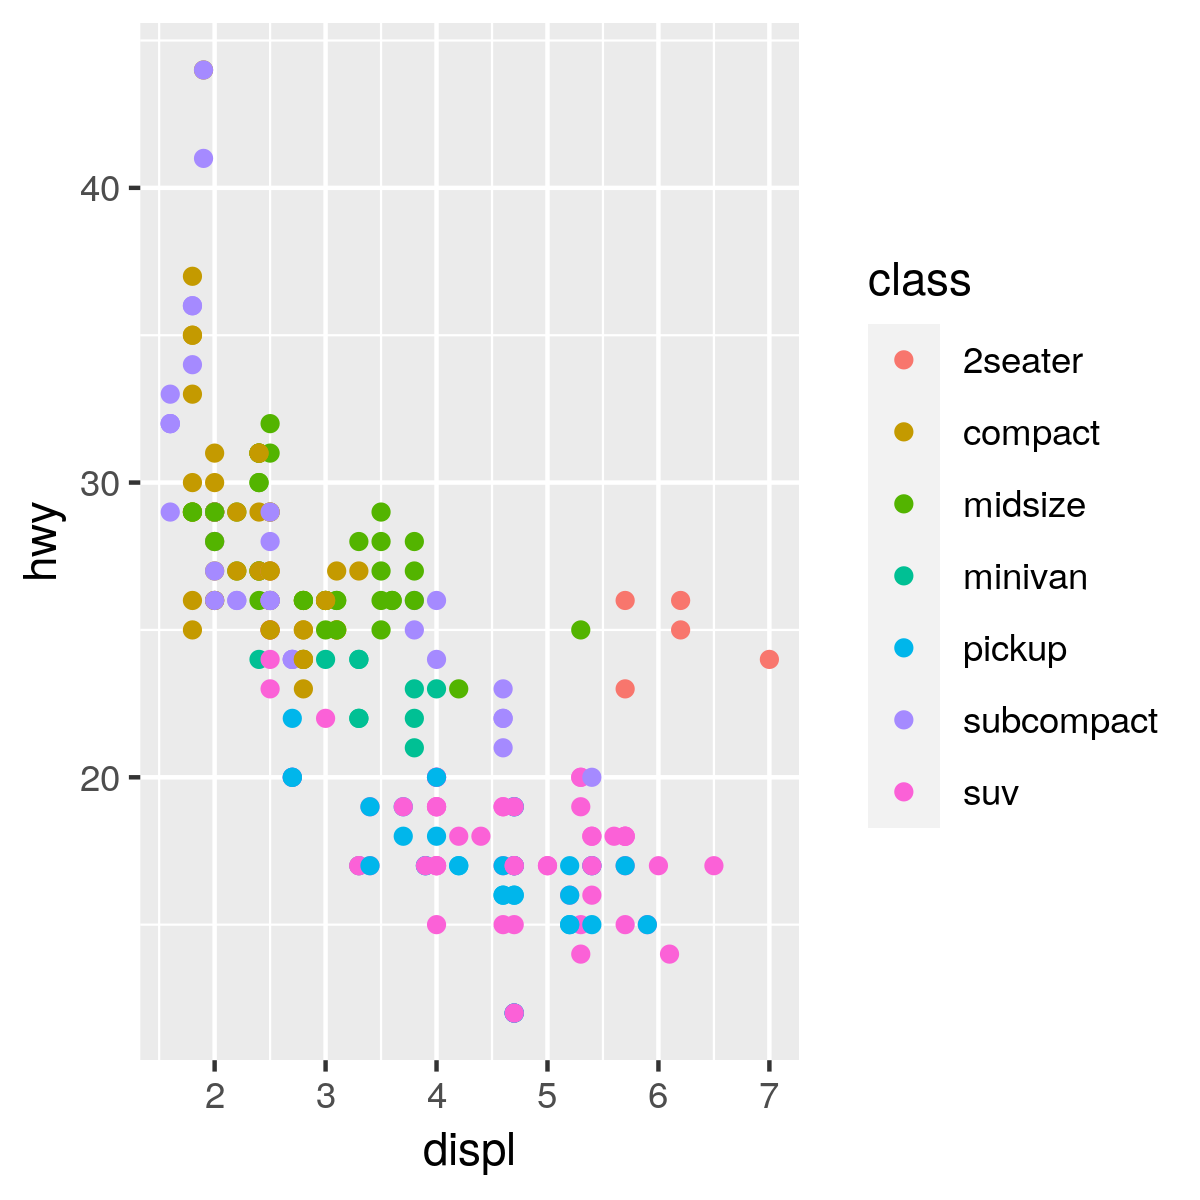

In [48]:
df=mpg
p=ggplot(df,aes(x=displ, y=hwy, color=class))+geom_point()
p

`-` 범례지우는방법1 

Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”


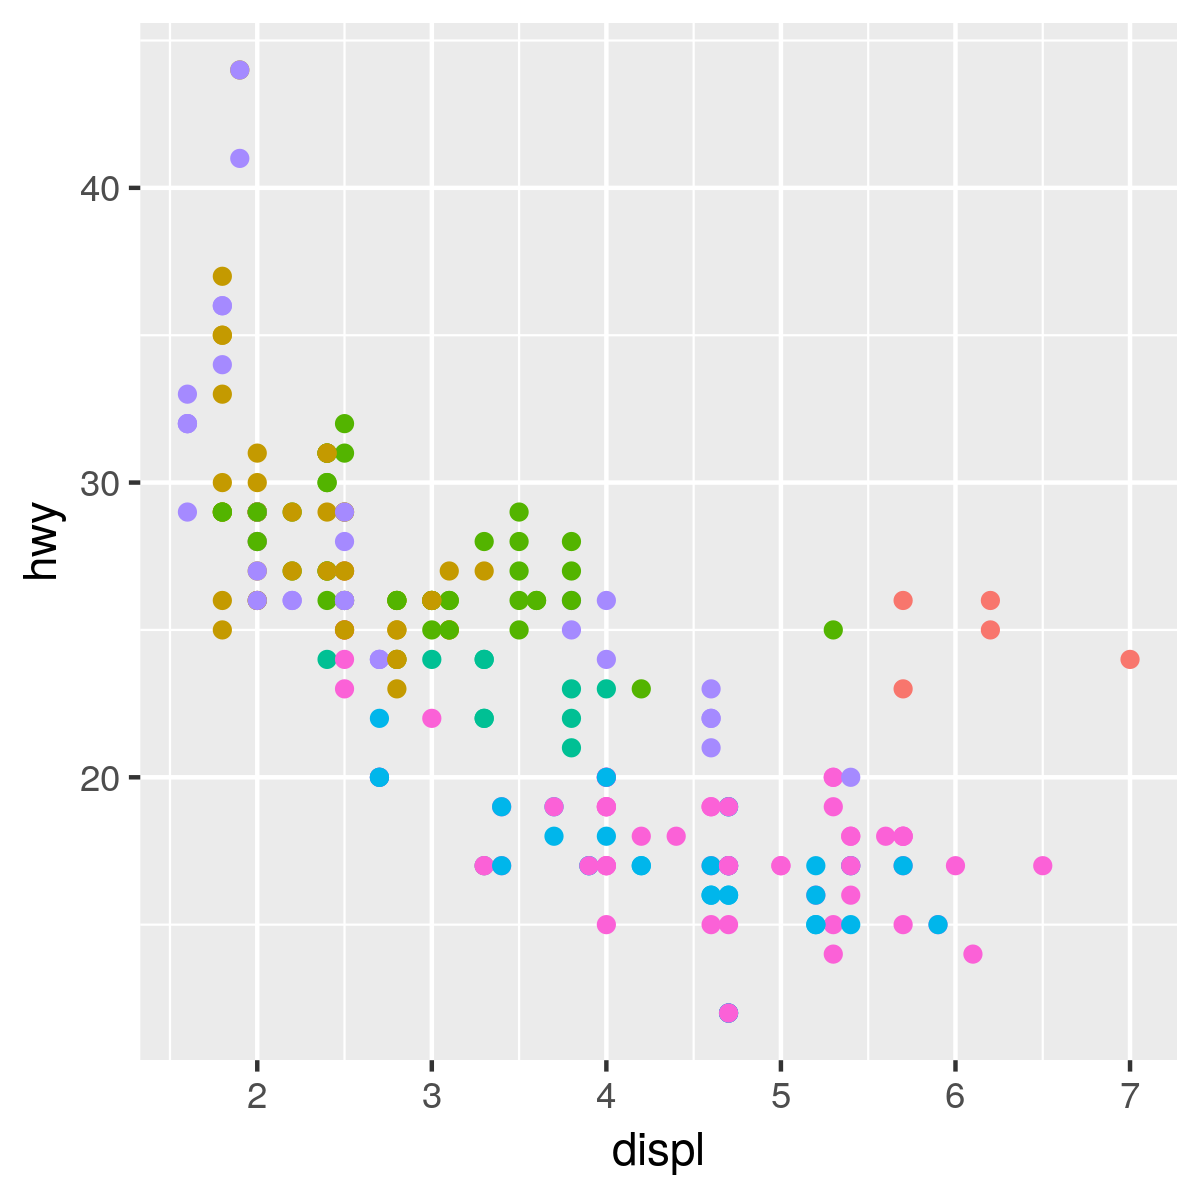

In [49]:
p+guides(color=F) ## 범례지우는 방법 1 

`-` 범례지우는방법2 

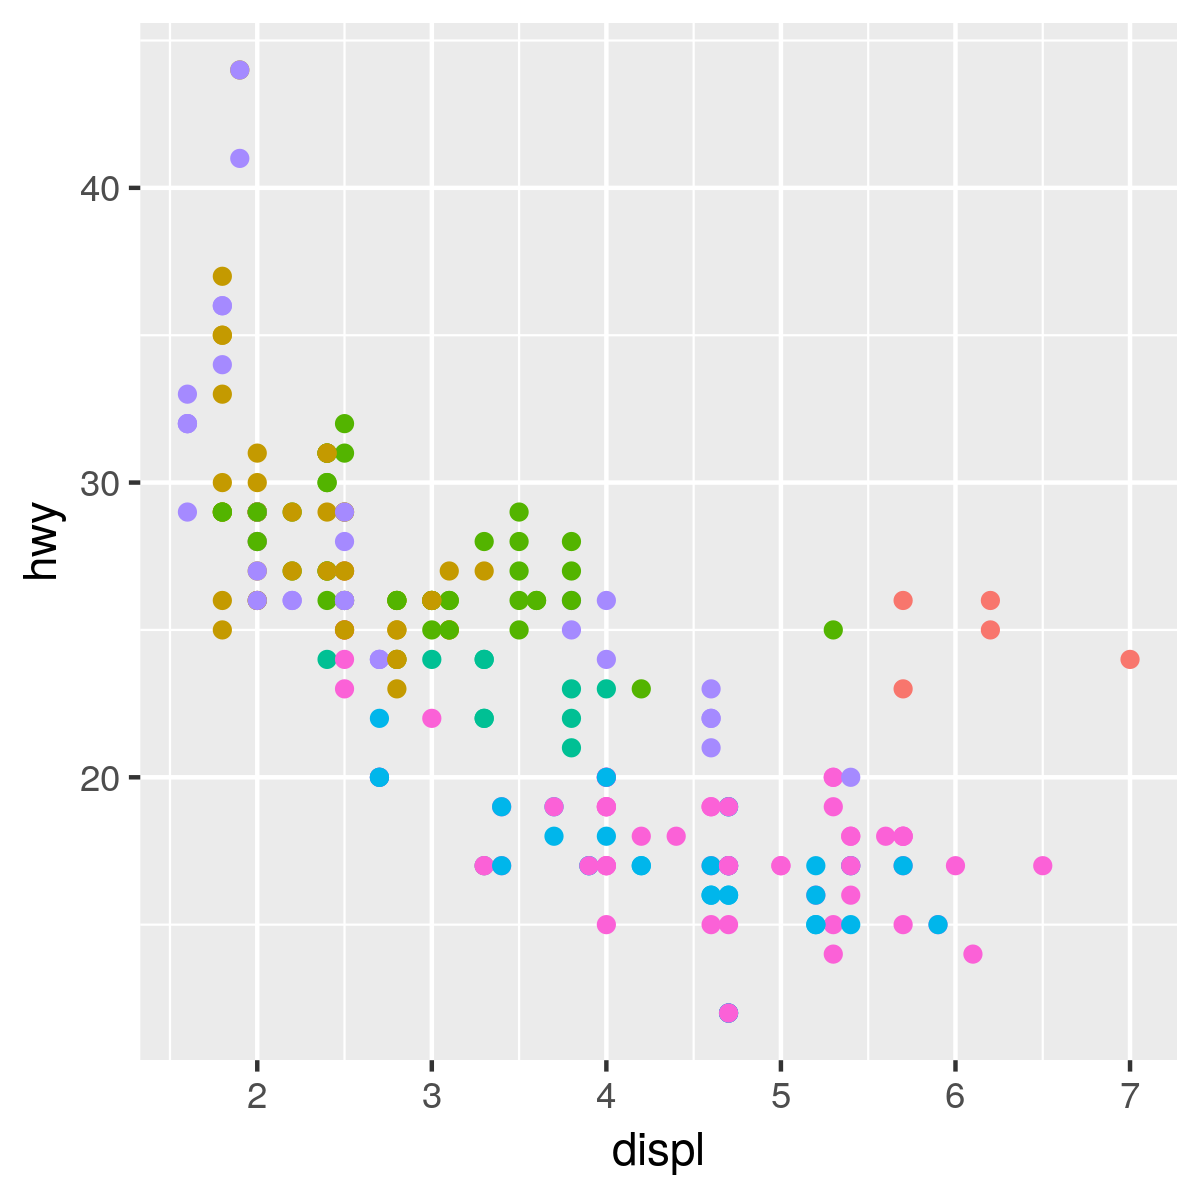

In [50]:
p+theme(legend.position = 'none')

### 범례의 크기조정 

`-` 예제그림

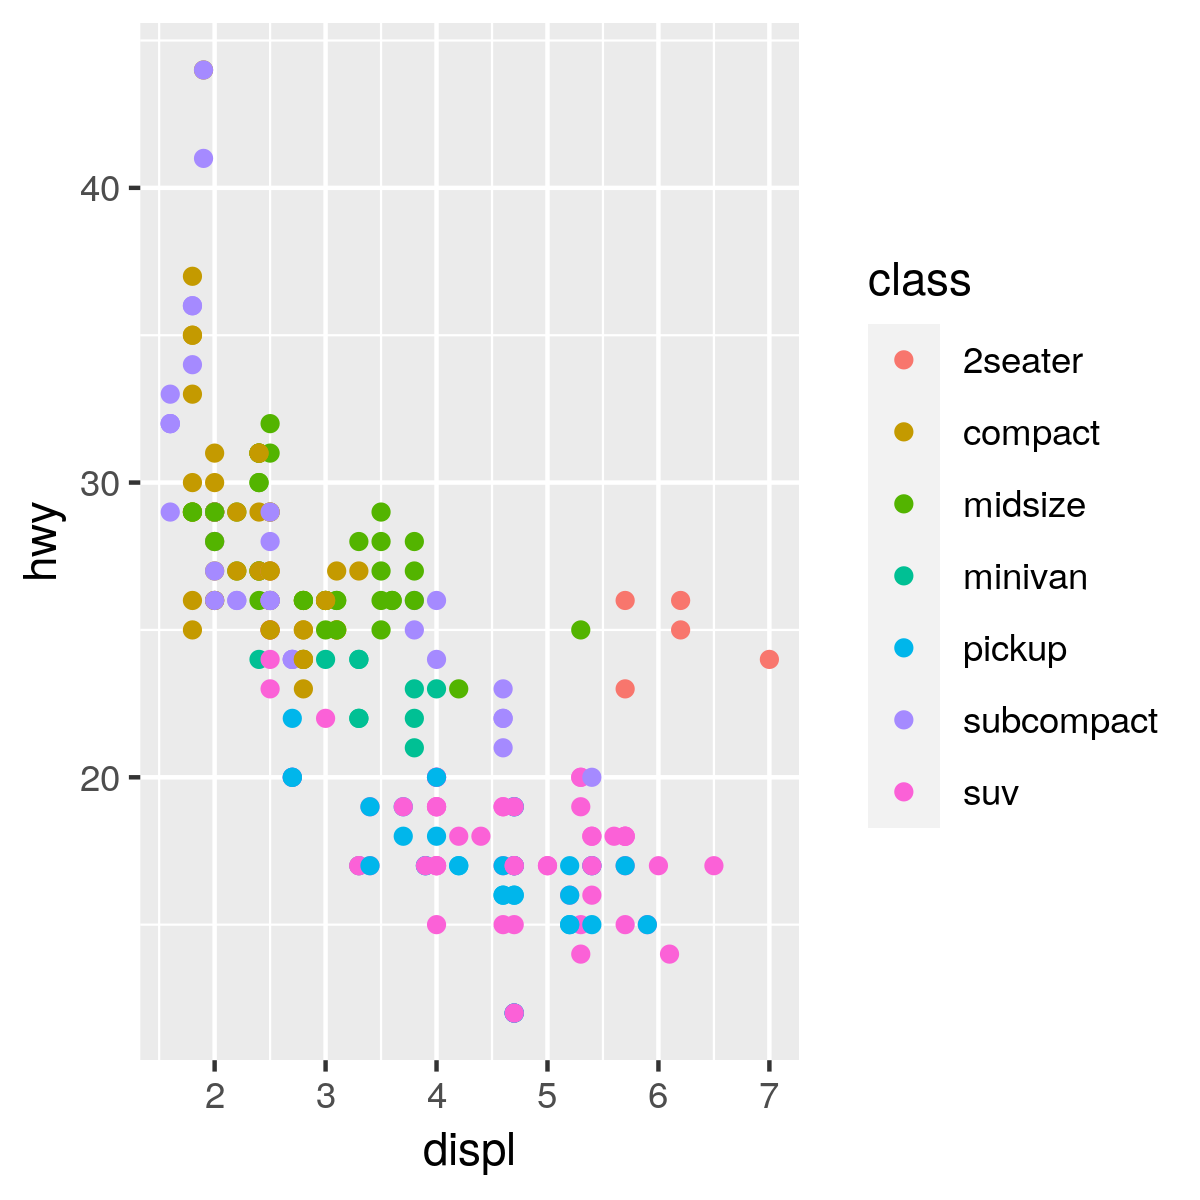

In [51]:
df=mpg
p=ggplot(df,aes(x=displ, y=hwy, color=class))+geom_point()
p

`-` 범례의 크기를 조정하는 방법은 아래와 같다. 

```r
...+theme(legend.key.width = unit(2,"mm"))
...+theme(legend.key.width = unit(4,"mm"))
```

이런식으로 하면 범례가 홀쭉해지기도 하고 뚱뚱해지기도 한다. HST에서 예제2번 칼라바를 홀쭉하게 만들때 사용하였다. 


### 범례제목내용변경



`-` 아래와 같이 하면 내용을 변경할 수 있다.
```r
...+labs(fill="Condition")
```
여기에서는 예제로 범례가 생성된 에스테틱이 fill이라고 가정하였다. 실제사용할때는 범례가 생성된 에스테틱에 맞춰서 사용하면 된다. 또는 아래와 같은 코드도 동일한 효과를 준다. 
```r
...+scale_fill_discrete(name="Condition")
```
하지만 labs를 쓰면 아래와 같이 2개이상의 범례도 바꿀 수 있다. 
```r
...+labs(fill="Condition",colour="Male/Female")
```

### 범례제목스타일변경

`-` 범례의 제목의 글씨체를 변경하고 싶다면 아래와 같이 하라. 
```r
### r
...+theme(legend.title=element_text(face='italic',size=14))
```

### legend

#### 범례제거

`-` 아래와 같이 guides()를 사용하고 범례를 없애고 싶은 에스테딕을 지정해준다.
```r
...+guides(alpha=FALSE)
```

`-` 만약에 모든 에스테틱에 대한 범례를 없애고 싶을때는 아래와 같이 테마시스템을 활용한다. 
```r
...+theme(legend.position="none")
```

#### 범례크기조정

`-` 범례의 크기를 조정하는 방법은 아래와 같다. 
```r
...+theme(legend.key.width = unit(2,"mm"))
...+theme(legend.key.width = unit(4,"mm"))
```
이런식으로 하면 범례가 홀쭉해지기도 하고 뚱뚱해지기도 한다. HST에서 예제2번 칼라바를 홀쭉하게 만들때 사용하였다. 


#### 범례제목스타일변경

`-` 범례의 제목의 글씨체를 변경하고 싶다면 아래와 같이 하라. 
```r
### r
...+theme(legend.title=element_text(face='italic',size=14))
```

#### 범례제목삭제
`-` 그냥 범례제목의 글꼴을 변경하는것 보다 범례제목 자체를 삭제하는게 나을수도 있다.
```r
...+guides(fill=guide_legend(title=NULL))
```


#### 범례에속한라벨변경
`-` scale함수군을 활용하여 범례를 컨트롤하면 범례에 속한 라벨을 하나하나 바꿀수 있다는 장점이 있다. 
```r
...+scale_colour_discrete(labels=c("M","F"))
...+scale_colour_discrete(labels=c("Male","Female"))
```

`-` 두개의 에스테틱을 동시에 적용하여 변수를 표현한 경우는 라벨도 동시에 바꿔줘야 한다. 예를들어 남자/여자를 구분하는데 칼라와 shape 에스테틱을 동시에 사용했다면 아래와 같이 한다. 
```r
...+scale_shape_discrete(labels=c("Male","Female"))+
	scale_colour_discrete(labels=c("Male","Female"))
```
당연한소리 같지만 이런식으로 안하면 shape, colour에 대한 두개의 라벨링이 따로 생긴다. 윈스턴 챙의 교재 p.228을 참고할것. 

### axis

#### 축 눈금제거 

`-` 축에서 y축의 숫자를 제거하고싶다면 아래와 같이 한다. 
```r
...+theme(axis.text.y=element_blank())
...+theme(axis.text.x=element_blank())
```

### subplot layout

#### grid.arrange

`-` grid.arrange를 사용하면 subplot을 적절히 배열할 수 있다. 
```r
grid.arrange(p1,p2,p3,p4,ncol=2,nrow=2)
```
다만 이런식으로 하면 모든 서브플랏들이 동일한 공간을 차지하게 된다. 여기에서 widths와 heights옵션을 사용하면 subplot들의 공간을 적절하게 배열할 수 있다. 
```r
p12 <- grid.arrange(p1,p2,ncol=2,widths=c(1,2))
p123 <- grid.arrange(p12,p3,nrow=2,heights=c(2,1))
p1234 <- grid.arrange(p123,p4,ncol=2,widths=c(1,2))
```
이 기능이 거의 사기적이므로 잘 이용하자. 

### facet 

#### axis-limit공유해제

`-` facet의 axis-limit을 공유하고 싶지 않다면 아래와 같이 하면 된다. 
```r
...+facet_grid(variable~mode, scales = "free")
```

#### facet-title의 스타일변경

`-` facet의 글씨모양을 변경하고 싶다면 아래와 같이 한다.
```r
...+theme(strip.text.x = element_text(size = 25, color = "black", face = "bold.italic"))
...+theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))
```


### ggtitle

#### 제목을 2줄로 
`-` 제목을 2줄로 하고싶으면 \n을 활용한다. 
```r
...+ggtitle("line1\nline2")
```

#### 제목스타일변경 
`-` 가장 많이 조정하는것은 아래처럼 글씨체를 바꾸는 것이다.
```r
...+theme(plot.title=element_text(face="bold.italic"))
```
그외에 제목의 외형을 변경하고 싶다면 아래를 참고하자. 
``` r
...+theme(plot.title=element_text(
	size=rel(1.5),
	lineheight=0.9,
	family="Times", # Helvetica, Times, Courier.
	face="bold.italic", # plain, bold, italic, bold.italic.
	colour="red",
	hjust=0, #0:left, 0.5=center, 1=right.
	vjust=0, #0:bottom, 0.5=center, 1=top.
	angle=0
	))
```
어지간한 옵션은 다 이해될것인데 lineheight는 뭔지 잘 모를것이다. 이것은 제목이 2줄일경우 줄간격을 설정하게 해주는 옵션이다. 

### scale

#### gradien

`-` 스케일에 그라디언트를 넣고 싶으면 아래와 같이 하라. 
```r
...+scale_fill_gradient(low="red",high="blue")
```
이것은 빨강에서 시작해서 파랑으로 변하는 그라디언트를 만들어 준다. 
```r
...+scale_fill_gradient2(low="red",high="blue",mid="white",midpoint=25)
```
이것은 빨강에서 시작해서 하양을거쳐 파랑으로 끝나는 그라디언트를 만들어 준다. 하양지점에 해당하는 값은 25이다. 

### ggsave
#### transparent
`-` 그림을 투명하게 저장하고 싶다면 우선 ggpubr 패키지를 로드한뒤에 아래와 같이 하라. <br/><br/>
```r
library(ggpubr)
p<-p+theme_transparent()
ggsave(plot=p,"p.png")
```
그런데 이렇게하면 배경이 다 날아간다. (좀더 탐구해봐야할듯) 동일한 코드를 파이썬으로 짜고싶다면 아래와 같이 하면 된다. 
```python
### python
p.savefig('temp.png', transparent=True)
```
여기에서 p는 그림 객체임. 